# Linear Regression
### The oldest machine-learning algorithm still in daily use

---

> *"Regression to mediocrity in hereditary stature."*
> — Francis Galton, Journal of the Anthropological Institute, 1886

---

Linear regression is the method that made all the others possible. When Adrien-Marie Legendre published the least-squares principle in 1805, and Carl Friedrich Gauss formalised its probabilistic foundation four years later, they were not thinking about machine learning, they were trying to fit orbits to the wandering asteroid Ceres. Eighty years later, Francis Galton was measuring the heights of parents and children and noticed that tall parents tended to have slightly shorter children, and short parents slightly taller — an effect he called *"regression towards mediocrity"*, and a word that still names the entire discipline two centuries later. Every supervised-learning algorithm you will meet later in this section — random forests, gradient boosting, neural networks — is, in a meaningful mathematical sense, a generalisation of or a reaction to the humble straight line Legendre and Gauss wrote down.

This notebook focuses on linear regression — we will treat it as a complete, self-contained statistical method. By the end you will know not just how to type `lm()`, but what the function is actually doing, why it does it that way, what its four assumptions mean in biological terms, how to diagnose it when it fails, how to quantify uncertainty in its output through the bootstrap, and how to tell whether the model you have built will generalise to new data. The ideas here — loss functions, parameter estimation, bias and variance, diagnostics, uncertainty — will return in every subsequent parts of Machine Learning. Master them once and you will save yourself years of confusion.

#### Topics covered

1. A short history: Legendre, Gauss, Galton, and why *"regression"* is called that
2. The simple linear model as equation, geometry, and probability statement
3. The least-squares principle, visualised from first principles
4. The Gauss-Markov theorem and what it promises (and does not promise)
5. The four assumptions — **LINE** — and how to read each one from a diagnostic plot
6. Fitting in R, with a full walk-through of the `summary()` output
7. Confidence intervals versus prediction intervals — a distinction that matters
8. Residual diagnostics redesigned as a single publication-ready quadrant
9. Influence, leverage, and Cook's distance — detecting high-impact observations
10. Multiple regression, and the interpretation of *"all else equal"*
11. Interactions — different slopes for different subgroups
12. Uncertainty via the nonparametric bootstrap
13. Evaluating prediction on held-out data: RMSE, MAE, out-of-sample R²
14. Where linear regression breaks, and why part 03 exists

#### R packages required

```r
install.packages(c("tidyverse", "patchwork", "showtext",
                   "ggridges", "palmerpenguins", "scales", "broom"))
```


### Libraries and visual theme

Every notebook in Machine Learning shares a common visual identity so that figures from different chapters sit comfortably alongside one another. Run this block once at the top of every session.

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)      # dplyr + ggplot2 + friends
  library(patchwork)      # composing multi-panel figures
  library(showtext)       # Google Fonts in ggplot
  library(scales)         # axis formatting
  library(broom)          # tidy() and augment() for model output
  library(palmerpenguins) # our running example dataset
})

options(repr.plot.width = 13, repr.plot.height = 7.5, repr.plot.res = 180)

font_add_google("Playfair Display", "playfair")
font_add_google("Montserrat",       "mont")
font_add_google("Fira Code",        "fira")
showtext_auto()

In [2]:
theme_ml <- function(base_size = 11) {
  theme_minimal(base_family = "mont", base_size = base_size) +
    theme(
      plot.background   = element_rect(fill = "#fafafa", colour = NA),
      panel.background  = element_rect(fill = "#ffffff", colour = NA),
      panel.grid.major  = element_line(colour = "#eeeeee", linewidth = 0.4),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(colour = "#dddddd", fill = NA, linewidth = 0.5),
      plot.title        = element_text(family = "playfair", face = "bold",
                                       size = base_size * 1.6, colour = "#1a1a2e",
                                       margin = margin(b = 6)),
      plot.subtitle     = element_text(size = base_size * 0.95, colour = "#4a4a6a",
                                       margin = margin(b = 10)),
      plot.caption      = element_text(size = base_size * 0.72, colour = "#9a9ab0",
                                       hjust = 0, margin = margin(t = 10)),
      axis.title        = element_text(colour = "#1a1a2e", size = base_size * 0.9,
                                       face = "bold"),
      axis.text         = element_text(colour = "#5a5a7a", size = base_size * 0.82),
      legend.position   = "bottom",
      legend.title      = element_text(face = "bold", colour = "#1a1a2e",
                                       size = base_size * 0.85),
      legend.text       = element_text(colour = "#4a4a6a", size = base_size * 0.8),
      strip.background  = element_rect(fill = "#1a1a2e", colour = NA),
      strip.text        = element_text(colour = "white", face = "bold",
                                       size = base_size * 0.85),
      plot.margin       = margin(16, 20, 12, 16)
    )
}

# Colour palettes
PalDiscrete   <- c("#e63946", "#457b9d", "#2a9d8f", "#e9c46a",
                   "#f4a261", "#6c5ce7", "#264653", "#b5838d")
PalDiverging  <- c("#2166ac", "#92c5de", "#f7f7f7", "#f4a582", "#d6604d")
PalSequential <- c("#fff9f0", "#fdd49e", "#fdbb84", "#fc8d59", "#d7301f", "#7f0000")
PalRedGreen   <- c("#2a9d8f", "#88c999", "#e9c46a", "#f4a261", "#e76f51", "#c1121f")

## A short history

The story begins in astronomy, not biology. In 1801 the Italian astronomer [Giuseppe Piazzi](https://mathshistory.st-andrews.ac.uk/Biographies/Piazzi/) observed a moving speck he took to be a new planet and named Ceres; weeks later, before anyone had enough observations to pin down its orbit, Ceres slipped behind the sun and was lost. Across Europe, astronomers scrambled to predict where it would re-emerge. The young [Carl Friedrich Gauss](https://mathshistory.st-andrews.ac.uk/Biographies/Gauss/) won this race using a method he had developed privately but never published: given a handful of noisy measurements of the asteroid's position, find the orbital parameters that minimise the sum of squared deviations between the orbit's predicted positions and the observations. When Ceres reappeared almost exactly where Gauss had predicted, least squares became overnight famous. [Adrien-Marie Legendre](https://mathshistory.st-andrews.ac.uk/Biographies/Legendre/) had in fact published the same idea four years earlier, in 1805, and the ensuing priority dispute between the two men occupied much of their correspondence for the next decade.

The move from astronomy to biology came through [Francis Galton](https://collections.countway.harvard.edu/onview/exhibits/show/galtonschildren/sir-francis-galton). In the 1880s, Galton, a cousin of Charles Darwin, and a man whose legacy includes both genuine statistical innovation and deeply troubling contributions to eugenics, was measuring the heights of parents and children in an attempt to understand heredity. He noticed that very tall parents tended to have children who were taller than average but *less* tall than themselves, and very short parents had children who were shorter than average but less short than themselves. He called this phenomenon *"regression towards mediocrity"*. The specific biological interpretation has long since been replaced by our understanding of genetics, but the word *regression* stuck, and from Galton's scatter-plot of parent and child heights the modern field of applied regression analysis can be said to have emerged. Karl Pearson, Galton's most influential student, formalised the mathematics; Ronald Fisher, a generation later, embedded it in the maximum-likelihood framework that still underpins how we teach the subject today.

The practical upshot for us, in 2026, is that when you type `lm()` in R you are invoking a method that has been refined continuously for two hundred and twenty years, whose mathematical properties are understood in extraordinary depth, and whose interpretation is built into the daily vocabulary of every quantitative science.

## The simple linear model

The simple linear regression model writes the response variable $y$ as a straight-line function of a single predictor $x$ plus random noise:

$$
y_i \;=\; \beta_0 \;+\; \beta_1\, x_i \;+\; \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0,\sigma^2),\quad i = 1,\dots,n.
$$

There is a great deal packed into this single line and it is worth slowing down to unpack every piece. The quantity $y_i$ is the response or outcome for the $i$-th observation — the body mass of the $i$-th penguin, for instance. The quantity $x_i$ is the predictor for that same observation — the penguin's flipper length. The coefficient $\beta_0$ is the **intercept**: the value we would predict for $y$ when $x = 0$. In many ecological applications this corresponds to a biologically impossible situation (no penguin has a zero-millimetre flipper), but it remains a necessary mathematical anchor for the line. The coefficient $\beta_1$ is the **slope**: the change in the expected value of $y$ associated with a one-unit increase in $x$. When someone asks *"what does regression tell me about how flipper length relates to body mass?"*, they are asking about $\beta_1$.

The final piece, $\varepsilon_i$, is the **error term**. It is the part of $y_i$ that the model cannot explain, and we assume it is drawn independently for each observation from a normal distribution with mean zero and variance $\sigma^2$. That assumption has real content: it says the scatter of points around the line is symmetric, is the same at every $x$, and does not carry memory from one observation to the next. When we talk about the assumptions of linear regression, we are talking about what this single line implies.

There are at least three complementary ways to visualise the same equation. The **geometric** view sees the model as the line that best passes through a cloud of points. The **probabilistic** view sees it as a family of conditional normal distributions, one at each value of $x$, whose means march up and down the line. The **optimisation** view sees it as the solution to a minimisation problem — find the line that makes the sum of squared vertical distances from the points to the line as small as possible. All three views are correct and the best practitioners keep all three in mind simultaneously.



## The least-squares principle

The task of fitting the line is a problem of *estimation*: we have the data but we do not know $\beta_0$ and $\beta_1$; we must choose values $\hat\beta_0$ and $\hat\beta_1$ that best summarise the relationship in the data. The least-squares principle, due to Legendre and Gauss, proposes a specific answer: choose the values that minimise the **residual sum of squares**,

$$
\mathrm{RSS}(\beta_0, \beta_1) \;=\; \sum_{i=1}^{n} \bigl( y_i - \beta_0 - \beta_1 x_i \bigr)^2.
$$

There are two common justifications for squaring. The first is geometric: squaring turns negative and positive residuals into contributions of the same sign, preventing cancellation, while also penalising large residuals more than small ones — the line works harder to avoid disasters than it does to split hairs. The second is probabilistic: if the errors really are normally distributed with constant variance, then the least-squares estimator is exactly the maximum-likelihood estimator, and it inherits all the optimality properties of that broader framework. You do not need to follow the maximum-likelihood argument yet to use regression well, but it is useful to know that two quite different starting points lead to the same algorithm.

The figure below shows this principle at work on a small simulated dataset. We have drawn three candidate lines through the data. For each line we have coloured the residual segments, the vertical drops from each point to the line, using a heat scale where small residuals appear cool and large residuals appear hot. The sum of squared residuals is shown as an annotation in the corner of each panel. The least-squares fit, in the rightmost panel, is the line for which that number is as small as it can possibly be.

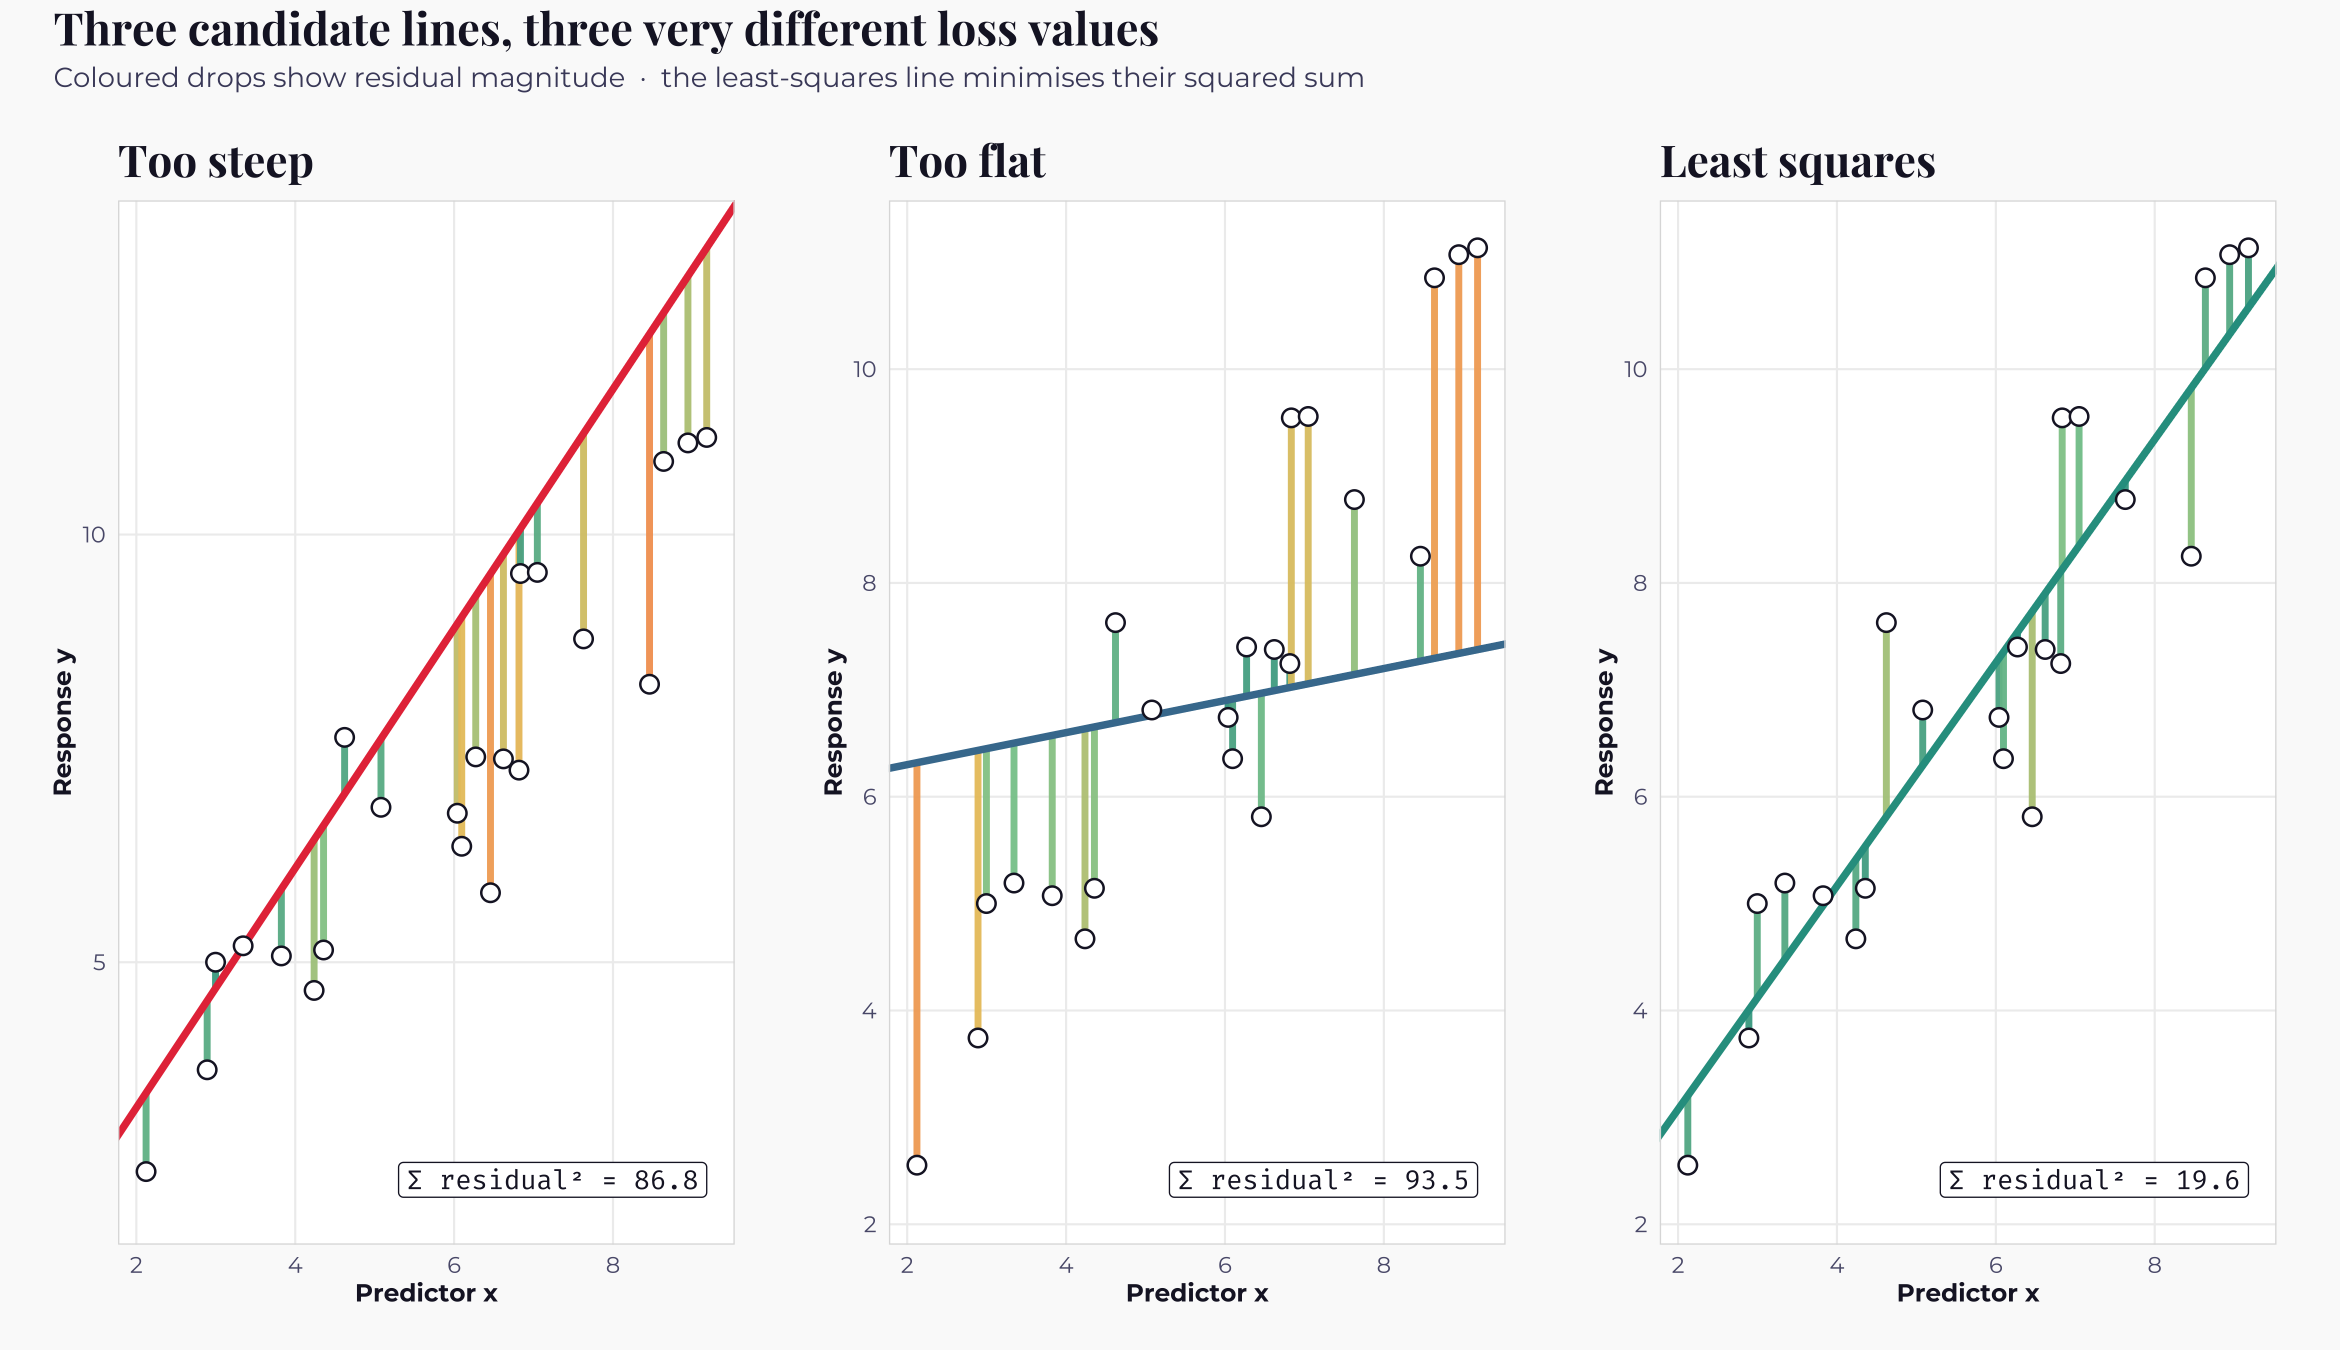


### The loss surface — where the three candidate lines really live

A scatter-plot with three lines on it is only half the story. Every candidate line $(\beta_0, \beta_1)$ corresponds to a single point in a two-dimensional **parameter space**, and the function $\mathrm{RSS}(\beta_0, \beta_1)$ defines a **loss surface** over that space — a landscape of hills and valleys whose lowest point is the least-squares solution. When you type `lm()`, what R returns is the coordinates of that minimum.

The figure below plots this landscape directly. The background is a contour map of $\log\mathrm{RSS}$ across a generous grid of $(\beta_0, \beta_1)$ values, coloured from dark (low loss, the valley floor) to light (high loss, the hillsides). The three candidate lines from the previous figure are marked as points on this map. Notice that the least-squares solution sits at the bottom of the valley, while the too-steep and too-flat candidates live up on the slopes — not catastrophically far from the minimum, but measurably worse. This surface happens to be a perfect elliptical bowl, which is why the problem has a clean closed-form solution; for GLMs (Part 03) and beyond, the surface is more irregular and we need iterative algorithms to find the bottom.

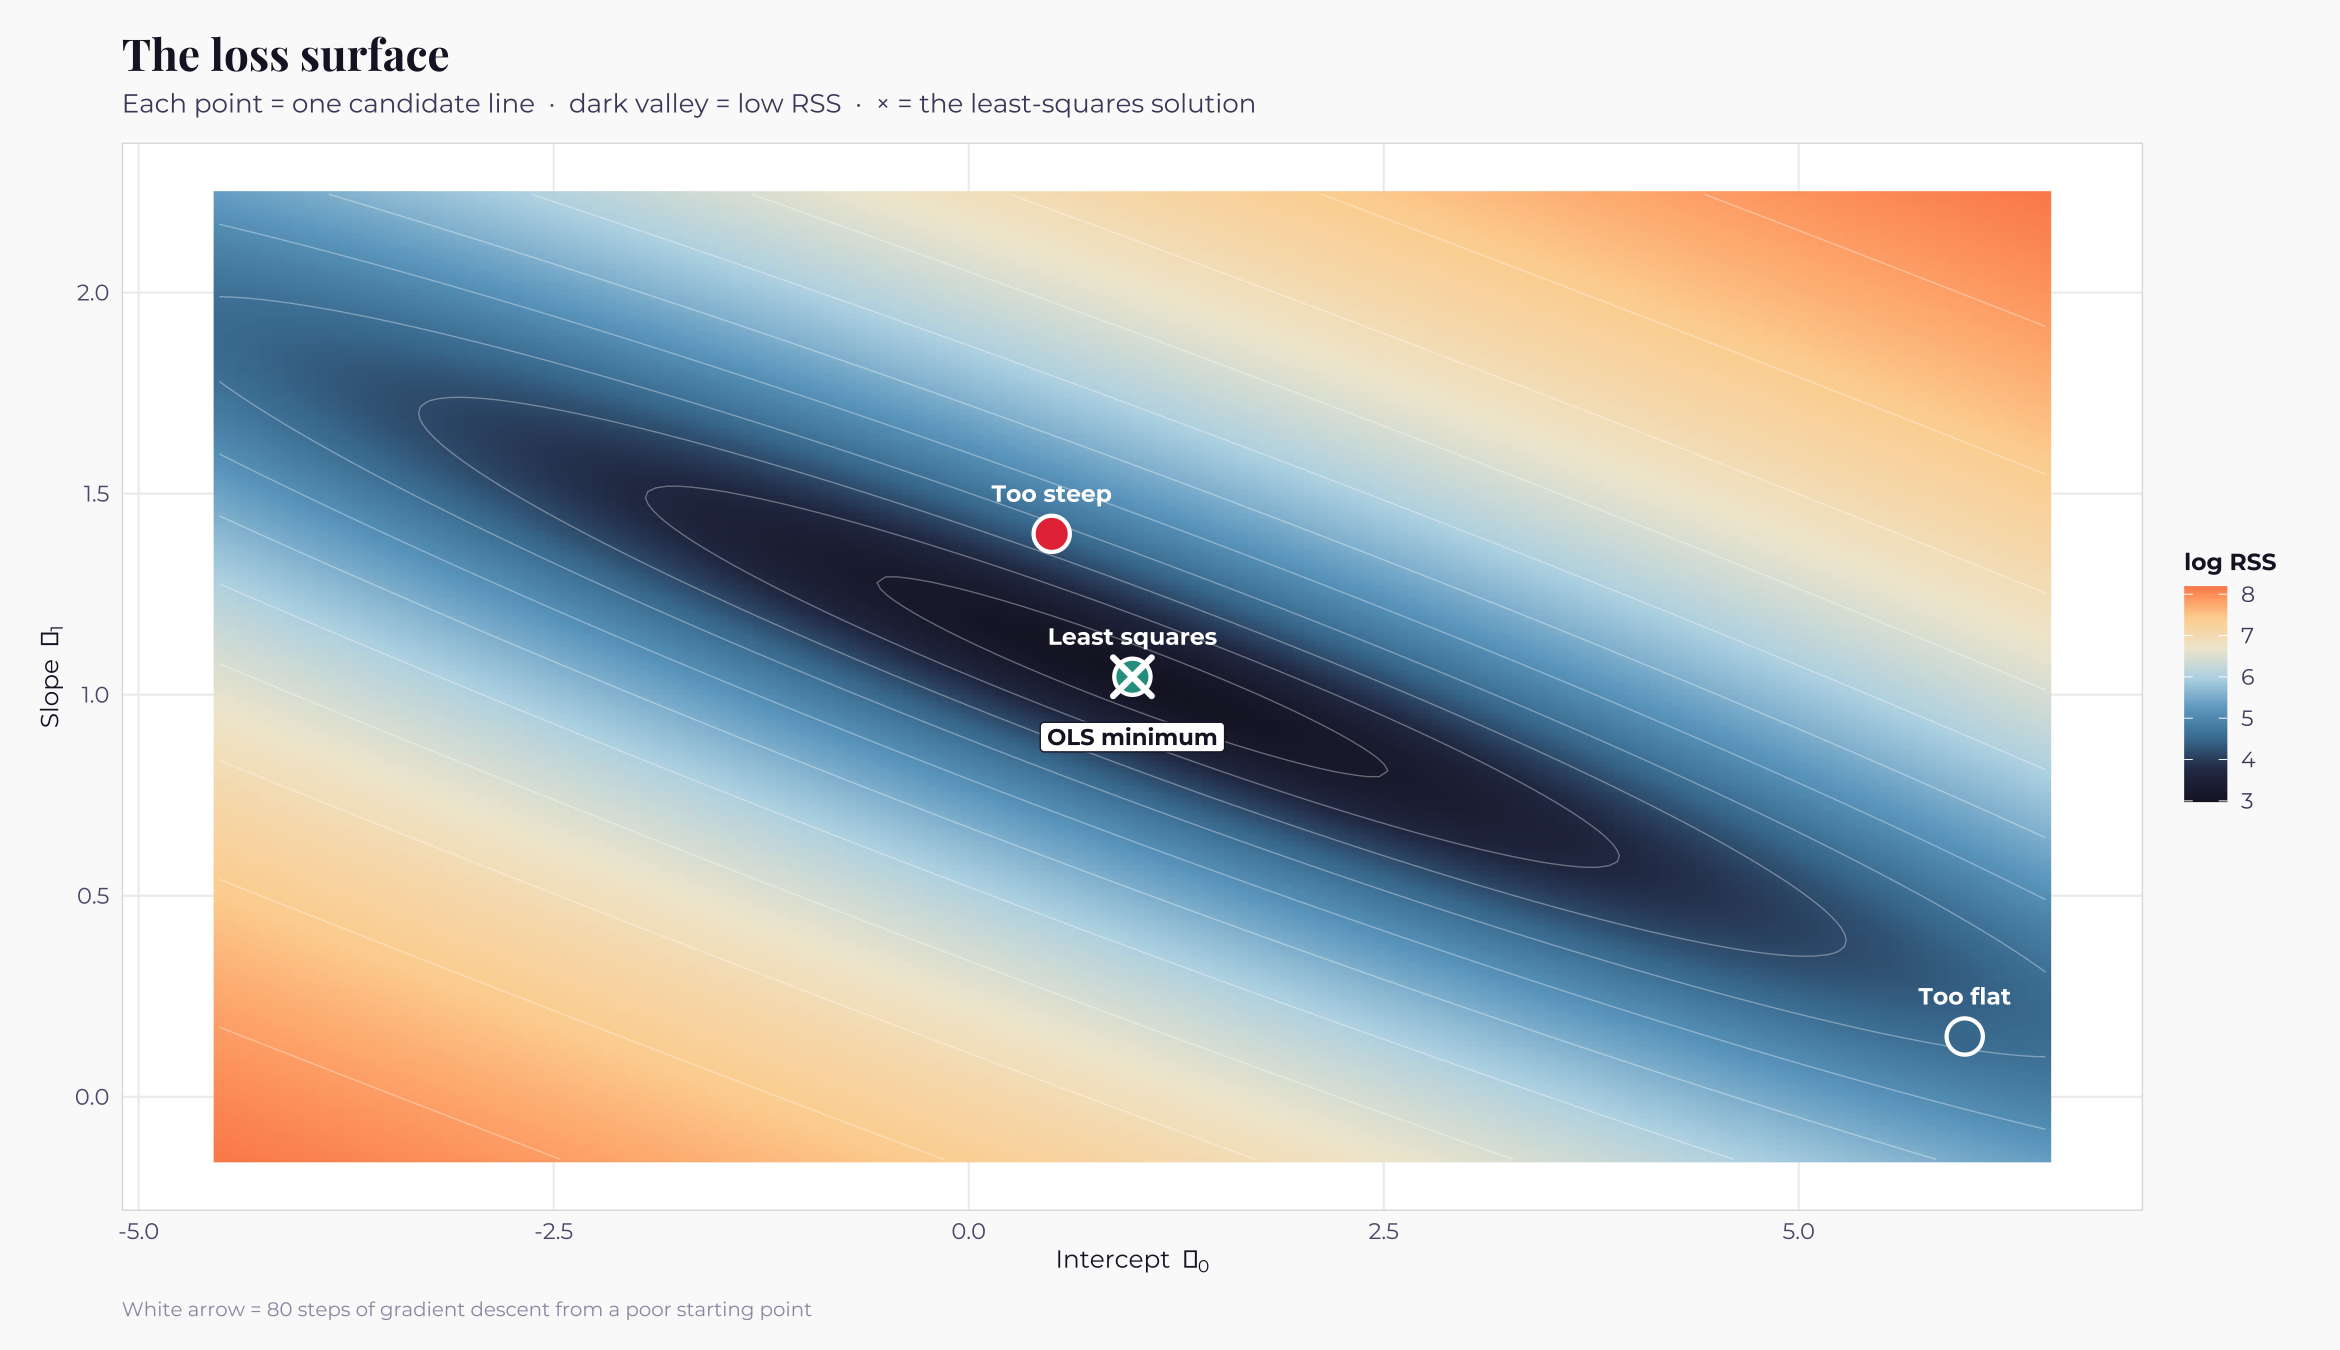

The white trail on the surface is the path a simple optimisation algorithm — gradient descent — would take from a deliberately poor starting point down to the minimum. For a linear regression we never actually need to walk the surface, because calculus gives us the answer in closed form, but the picture matters because almost every later algorithm *does* need to walk a loss surface. Logistic regression, GLMs, GAMs, neural networks, gradient boosting — all of them are, at their core, iterative searches on a multi-dimensional landscape exactly like this one. Linear regression is the easy case because its landscape is perfectly convex, with one global minimum and no local traps. Later Parts will show you what happens when the landscape becomes more interesting.

### The closed-form solution

For the simple (one-predictor) case, the least-squares problem has a closed-form solution that can be derived with ordinary calculus. Setting the partial derivatives of RSS with respect to $\beta_0$ and $\beta_1$ equal to zero and solving yields

$$
\hat\beta_1 \;=\; \frac{\sum_i (x_i - \bar x)(y_i - \bar y)}{\sum_i (x_i - \bar x)^2}, \qquad \hat\beta_0 \;=\; \bar y - \hat\beta_1 \bar x,
$$

where $\bar x$ and $\bar y$ are the sample means. You do not need to commit these formulae to memory — `lm()` will happily compute them for you — but it is worth noticing that the slope estimator is a ratio of the sample covariance between $x$ and $y$ to the sample variance of $x$. This exposes a fundamental fact about regression: no variation in $x$ means no estimable slope. If you survey every pond at exactly the same pH, no amount of clever mathematics will tell you anything about the effect of pH on, say, newt abundance.

## What least squares guarantees — the Gauss-Markov theorem

The least-squares estimator has a property so famous it has its own theorem, named after the two men who independently discovered it. The **Gauss-Markov theorem** states that, under a specific set of assumptions we will introduce in the next section, the ordinary least-squares estimator is the **best linear unbiased estimator** of $\beta$ — abbreviated BLUE. *Unbiased* means that, on average across many hypothetical repeated samples, the estimator hits the true value. *Best* means it has the smallest variance among all unbiased estimators that are linear functions of $y$. In other words, if your data really do satisfy the standard assumptions, no other linear method can do better on average than OLS. This is a remarkable promise and it explains why least squares remained unchallenged as *the* default method for over a century and a half.

The theorem is also a cautionary tale. It promises optimality *if and only if* the assumptions hold. When they do not, and in ecology they often do not, the OLS estimator is still unbiased in most cases, but its standard errors become unreliable, its confidence intervals become miscalibrated, and its p-values stop meaning what you think they mean. The techniques we will meet in Parts 03, 04, and 17 are all, in various ways, responses to this warning. Before we break the assumptions, however, we need to state them clearly.

## The four assumptions — LINE

The assumptions of linear regression are traditionally taught with the acronym **LINE**, which is slightly unfair because only the first letter concerns linearity, but the mnemonic has stuck and it does the job.

The **L**inearity assumption says that the conditional mean of $y$ given $x$ is a straight-line function of $x$. It does *not* say that $y$ itself is distributed linearly — that would not even make sense — and it does not say that $y$ and $x$ are deterministic. It says only that if you took every observation at a given value of $x$ and averaged their $y$ values, those averages would fall on a straight line as $x$ varies. If the true relationship curves, bends, plateaus, or wiggles, OLS can still be fit but its interpretation is badly corrupted.

The **I**ndependence assumption says that, conditional on the predictors, the errors do not carry information from one observation to the next. Spatially nearby pixels, temporally close measurements, and repeated measurements on the same individual all violate this assumption, often severely. Violations inflate the apparent precision of our estimates because the effective sample size is smaller than we pretend. Dealing properly with non-independence requires mixed-effects models, spatial regression, or time-series methods — topics beyond this notebook but essential in practice.

The **N**ormality assumption concerns the distribution of the residuals, not of $y$ itself. We assume that, around the fitted line, the residuals follow a normal distribution with mean zero. Mild departures from normality are surprisingly harmless thanks to the central limit theorem operating on the distribution of the estimators, but heavy tails and strong skew can distort inference, and they usually indicate that a different response distribution (Poisson, binomial, gamma) would fit better.

The **E**qual-variance assumption — also called homoscedasticity — says that the variance of the residuals is constant across all values of $x$. Violations, where variance grows or shrinks with the mean, are called heteroscedasticity and are extraordinarily common in ecological data. Count data typically have variance that grows with the mean; concentrations and biomasses have variance that grows roughly with the square of the mean. Ignoring heteroscedasticity rarely biases $\hat\beta$ but nearly always ruins the standard errors.

The figure below shows, in four columns, what each assumption looks like when it is satisfied (top row) and what a classic violation looks like (bottom row). Keep this figure mentally bookmarked — you will be looking for these patterns in your own diagnostic plots for the rest of your scientific career.

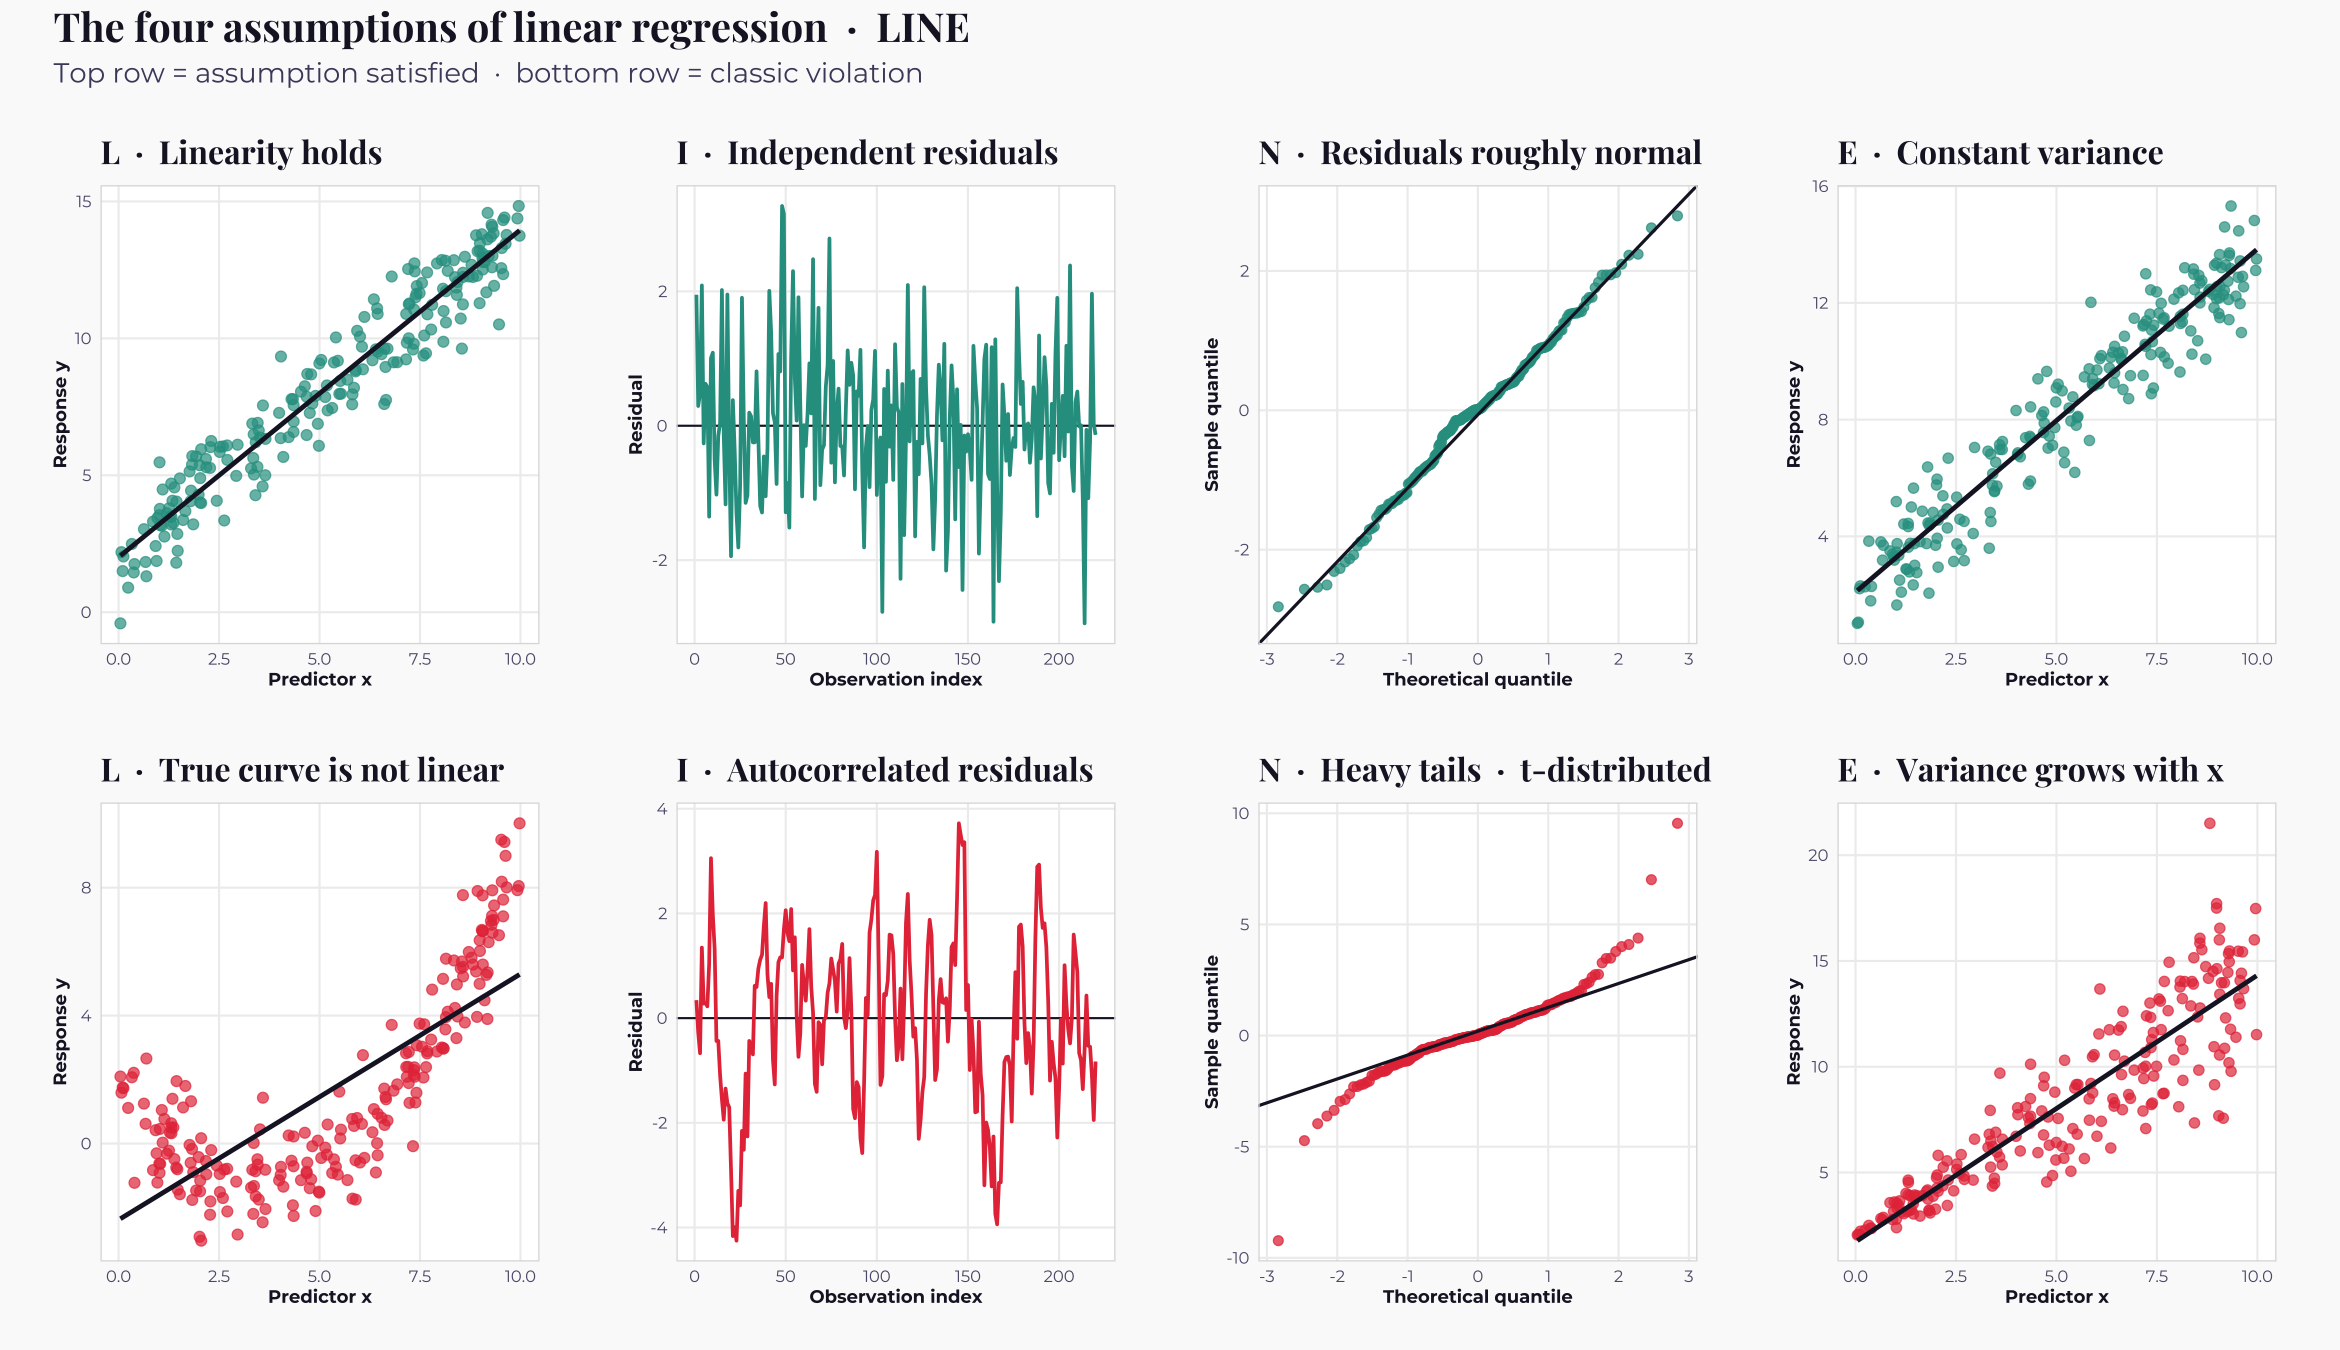

## Fitting a real model — Gentoo penguin body mass

We return to the Palmer penguins. Our question: **across Gentoo penguins at Biscoe Island, how does body mass scale with flipper length?** This is a straightforward allometric question of the kind ecologists ask constantly, and Gentoo penguins are a good choice because they are the largest of the three species in the dataset, with the widest range of flipper lengths — which, as we have just seen, is what allows us to estimate a slope in the first place. We will restrict ourselves to one species at this stage to keep the model simple and interpretable; we will add species and sex later in the notebook.

In [3]:
peng <- penguins %>% drop_na()
gentoo <- peng %>% filter(species == "Gentoo")

cat("Gentoo penguins with complete data:", nrow(gentoo), "\n")
glimpse(gentoo)

Gentoo penguins with complete data: 119 
Rows: 119
Columns: 8
$ species           <fct> Gentoo, Gentoo, Gentoo, Gentoo, Gentoo, Gentoo, Gent…
$ island            <fct> Biscoe, Biscoe, Biscoe, Biscoe, Biscoe, Biscoe, Bisc…
$ bill_length_mm    <dbl> 46.1, 50.0, 48.7, 50.0, 47.6, 46.5, 45.4, 46.7, 43.3…
$ bill_depth_mm     <dbl> 13.2, 16.3, 14.1, 15.2, 14.5, 13.5, 14.6, 15.3, 13.4…
$ flipper_length_mm <int> 211, 230, 210, 218, 215, 210, 211, 219, 209, 215, 21…
$ body_mass_g       <int> 4500, 5700, 4450, 5700, 5400, 4550, 4800, 5200, 4400…
$ sex               <fct> female, male, female, male, male, female, female, ma…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [4]:
fit <- lm(body_mass_g ~ flipper_length_mm, data = gentoo)
fit


Call:
lm(formula = body_mass_g ~ flipper_length_mm, data = gentoo)

Coefficients:
      (Intercept)  flipper_length_mm  
         -6674.20              54.17  


That is a complete and working linear regression. But the output printed to the console is only the tip of the iceberg. Almost everything you will want to know about the model is hidden in the `summary()` function.

In [5]:
summary(fit)


Call:
lm(formula = body_mass_g ~ flipper_length_mm, data = gentoo)

Residuals:
    Min      1Q  Median      3Q     Max 
-704.69 -244.29  -58.87  161.98 1003.65 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -6674.204   1075.436  -6.206 8.51e-09 ***
flipper_length_mm    54.165      4.948  10.946  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 354 on 117 degrees of freedom
Multiple R-squared:  0.506,	Adjusted R-squared:  0.5017 
F-statistic: 119.8 on 1 and 117 DF,  p-value: < 2.2e-16


### Reading `summary()` — every number, explained

The `summary()` output contains roughly five blocks of information and they are worth learning to read fluently. We will walk through each in turn.

The **Call** block simply repeats the formula you fitted. It is easy to overlook but it is your one immediate defence against accidentally interpreting the summary of the wrong model — a mistake that is astonishingly easy to make when you have ten `lm` objects in your environment.

The **Residuals** block reports the five-number summary of the residuals $y_i - \hat y_i$. The minimum and maximum tell you how badly wrong the worst-fitted observation is. The median should be approximately zero; a median noticeably far from zero suggests the residuals are systematically biased. The first and third quartiles give you a rough sense of spread. For a well-behaved model, the residuals should look like a symmetric distribution centred on zero.

The **Coefficients** block is the heart of the output. Each row corresponds to one term in the model. The first column, labelled `Estimate`, is the point estimate of the coefficient. The second column, `Std. Error`, is an estimate of the standard deviation of the sampling distribution of that estimate — informally, the uncertainty. The third column, `t value`, is just the ratio of estimate to standard error; under the null hypothesis that the true coefficient equals zero, this ratio follows a Student's *t*-distribution with $n - p$ degrees of freedom (where $p$ is the number of coefficients). The fourth column, `Pr(>|t|)`, is the two-sided p-value: the probability of observing a *t*-statistic at least this extreme under the null. The stars on the right are a visual shorthand for significance thresholds and should be ignored in polite company.

Below the coefficients are three summary statistics that describe the model as a whole. **Residual standard error** is an estimate of $\sigma$, the standard deviation of the error term. In our Gentoo model it is reported in grams, the same units as the response — a typical prediction error is roughly that many grams off. **Multiple R-squared**, the famous $R^2$, is the proportion of variation in $y$ that the model has explained; it ranges from 0 (the model explains nothing) to 1 (the model explains everything). **Adjusted R-squared** applies a small penalty for the number of predictors and is the better number to compare between models with different numbers of terms. Finally, the **F-statistic** with its p-value tests the global null hypothesis that none of the non-intercept coefficients differ from zero — in a single-predictor model, this is redundant with the *t*-test for the slope, but in multiple regression it becomes more interesting.

Let us extract the key numbers in a tidier form using the `broom` package.

In [6]:
library(broom)

tidy(fit, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), \(z) signif(z, 4)))

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-6674.00,1075.000,-6.206,8.506e-09,-8804.00,-4544.00
flipper_length_mm,54.17,4.948,10.950,1.249e-19,44.37,63.97


In [7]:
glance(fit) %>%
  select(r.squared, adj.r.squared, sigma, statistic, p.value, df, df.residual) %>%
  mutate(across(where(is.numeric), \(z) signif(z, 4)))

r.squared,adj.r.squared,sigma,statistic,p.value,df,df.residual
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.506,0.5017,354,119.8,1.249e-19,1,117


The interpretation, in plain ecological English: across Gentoo penguins, each additional millimetre of flipper length is associated with 54.17 grams of additional body mass, and we are 95% confident that the true population value lies between about 45 and 64 grams per millimetre. Flipper length alone accounts for approximately 50% of the variation in body mass — a respectable figure for a single ecological predictor, though it leaves half the variation on the table for other variables like sex, age, reproductive state, and seasonal condition. The typical prediction is off by several hundred grams, which gives you an honest sense of how tight the relationship really is.

Notice what we have *not* said. We have not said that flipper length *causes* increased body mass, nor the reverse. Regression is a tool for quantifying association, not causation. Causal inference requires either a controlled experiment or a carefully constructed causal diagram plus a lot of additional assumptions, and it is one of the most active areas of modern statistics in its own right.

## Visualising the fit — and two kinds of interval

Every report of a linear regression should be accompanied by the figure of the data with the fitted line overlaid. This is not optional. A model's point estimate can be misleading in ways that a single well-made figure makes immediately obvious — a lurking non-linearity, an outlier dragging the line, a gap in the data where we have no information. If you cannot picture a regression, you do not really understand it.

There are, however, two distinct kinds of uncertainty band that can be drawn around the fitted line, and confusing the two is one of the most common mistakes in applied regression. The **confidence interval** around the line quantifies our uncertainty about *the mean of $y$ at a given $x$*. It answers the question, *"If I took a huge population of Gentoo penguins all with 220-mm flippers, what would their average body mass be?"* The interval is narrow near the centre of the data and widens at the extremes because we have less information out there. The **prediction interval** quantifies our uncertainty about *a single new observation of $y$*. It answers a different question: *"If I catch one more Gentoo penguin with a 220-mm flipper, what is its body mass likely to be?"* Since a single new observation contains both the uncertainty about the mean *and* the irreducible noise $\sigma^2$, the prediction interval is always wider than the confidence interval. The figure below shows both simultaneously.

In [8]:
options(repr.plot.width = 14, repr.plot.height = 9)
library(tidyverse); library(patchwork)

new_x <- tibble(flipper_length_mm = seq(min(gentoo$flipper_length_mm),
                                        max(gentoo$flipper_length_mm),
                                        length.out = 300))
ci <- predict(fit, newdata = new_x, interval = "confidence") %>% as_tibble() %>%
  rename(ci_lo = lwr, ci_hi = upr)
pi <- predict(fit, newdata = new_x, interval = "prediction") %>% as_tibble() %>%
  rename(pi_lo = lwr, pi_hi = upr) %>% select(pi_lo, pi_hi)
band <- bind_cols(new_x, ci, pi)

In [9]:
# Main panel: scatter + line + both bands
P_main <- ggplot(gentoo, aes(flipper_length_mm, body_mass_g)) +
  geom_ribbon(data = band, aes(y = fit, ymin = pi_lo, ymax = pi_hi),
              fill = PalDiscrete[2], alpha = 0.10) +
  geom_ribbon(data = band, aes(y = fit, ymin = ci_lo, ymax = ci_hi),
              fill = PalDiscrete[2], alpha = 0.35) +
  geom_line(data = band, aes(y = fit), colour = "#1a1a2e", linewidth = 1.3) +
  geom_point(shape = 21, fill = PalDiscrete[4], colour = "#1a1a2e",
             size = 2.9, stroke = 0.5, alpha = 0.9) +
  # Annotation arrows showing CI vs PI width at the centre
  annotate("segment", x = 220, xend = 220,
           y = approx(band$flipper_length_mm, band$ci_lo, 220)$y,
           yend = approx(band$flipper_length_mm, band$ci_hi, 220)$y,
           colour = PalDiscrete[1], linewidth = 1.1,
           arrow = arrow(length = unit(0.15, "cm"), ends = "both")) +
  annotate("segment", x = 226, xend = 226,
           y = approx(band$flipper_length_mm, band$pi_lo, 226)$y,
           yend = approx(band$flipper_length_mm, band$pi_hi, 226)$y,
           colour = PalDiscrete[6], linewidth = 1.1,
           arrow = arrow(length = unit(0.15, "cm"), ends = "both")) +
  annotate("label", x = 220, y = 6200, label = "CI for the\nmean",
           family = "mont", size = 3.0, hjust = 0.5,
           colour = PalDiscrete[1], fill = "#ffffff", label.size = 0.15) +
  annotate("label", x = 226, y = 6200, label = "PI for a\nnew bird",
           family = "mont", size = 3.0, hjust = 0.5,
           colour = PalDiscrete[6], fill = "#ffffff", label.size = 0.15) +
  # Regression equation
  annotate("label", x = min(gentoo$flipper_length_mm) + 1,
           y = min(gentoo$body_mass_g) + 2000,
           label = sprintf("body mass \u2248 %.0f + %.1f \u00b7 flipper\nR\u00b2 = %.2f",
                           coef(fit)[1], coef(fit)[2], summary(fit)$r.squared),
           family = "fira", size = 3.8, hjust = 0, vjust = 0,
           fill = "white", colour = "#1a1a2e", label.size = 0.25) +
  scale_x_continuous(expand = expansion(mult = 0.01)) +
  scale_y_continuous(expand = expansion(mult = 0.01)) +
  labs(x = "Flipper length (mm)", y = "Body mass (g)") +
  theme_ml() +
  theme(plot.margin = margin(4, 6, 10, 10))

Warning message in annotate("label", x = 220, y = 6200, label = "CI for the\nmean", :
“Ignoring unknown parameters: `label.size`”
Warning message in annotate("label", x = 226, y = 6200, label = "PI for a\nnew bird", :
“Ignoring unknown parameters: `label.size`”
Warning message in annotate("label", x = min(gentoo$flipper_length_mm) + 1, y = min(gentoo$body_mass_g) + :
“Ignoring unknown parameters: `label.size`”


In [10]:
# Top marginal: density of x
P_top <- ggplot(gentoo, aes(flipper_length_mm)) +
  geom_density(fill = PalDiscrete[4], colour = "#1a1a2e",
               linewidth = 0.4, alpha = 0.8) +
  scale_x_continuous(limits = range(gentoo$flipper_length_mm),
                     expand = expansion(mult = 0.01)) +
  labs(title    = "Body mass rises with flipper length in Gentoo penguins",
       subtitle = "Dark ribbon = 95 % CI for the mean  \u00b7  faint ribbon = 95 % prediction interval for a new bird") +
  theme_void(base_family = "mont") +
  theme(plot.title    = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e",
                                     margin = margin(b = 4)),
        plot.subtitle = element_text(size = 11, colour = "#4a4a6a",
                                     margin = margin(b = 6)),
        plot.background = element_rect(fill = "#fafafa", colour = NA),
        plot.margin = margin(12, 6, 0, 10))

In [11]:
# Right marginal: density of y
P_right <- ggplot(gentoo, aes(y = body_mass_g)) +
  geom_density(fill = PalDiscrete[2], colour = "#1a1a2e",
               linewidth = 0.4, alpha = 0.7) +
  scale_y_continuous(limits = range(gentoo$body_mass_g),
                     expand = expansion(mult = 0.01)) +
  theme_void() +
  theme(plot.background = element_rect(fill = "#fafafa", colour = NA),
        plot.margin = margin(4, 10, 10, 0))

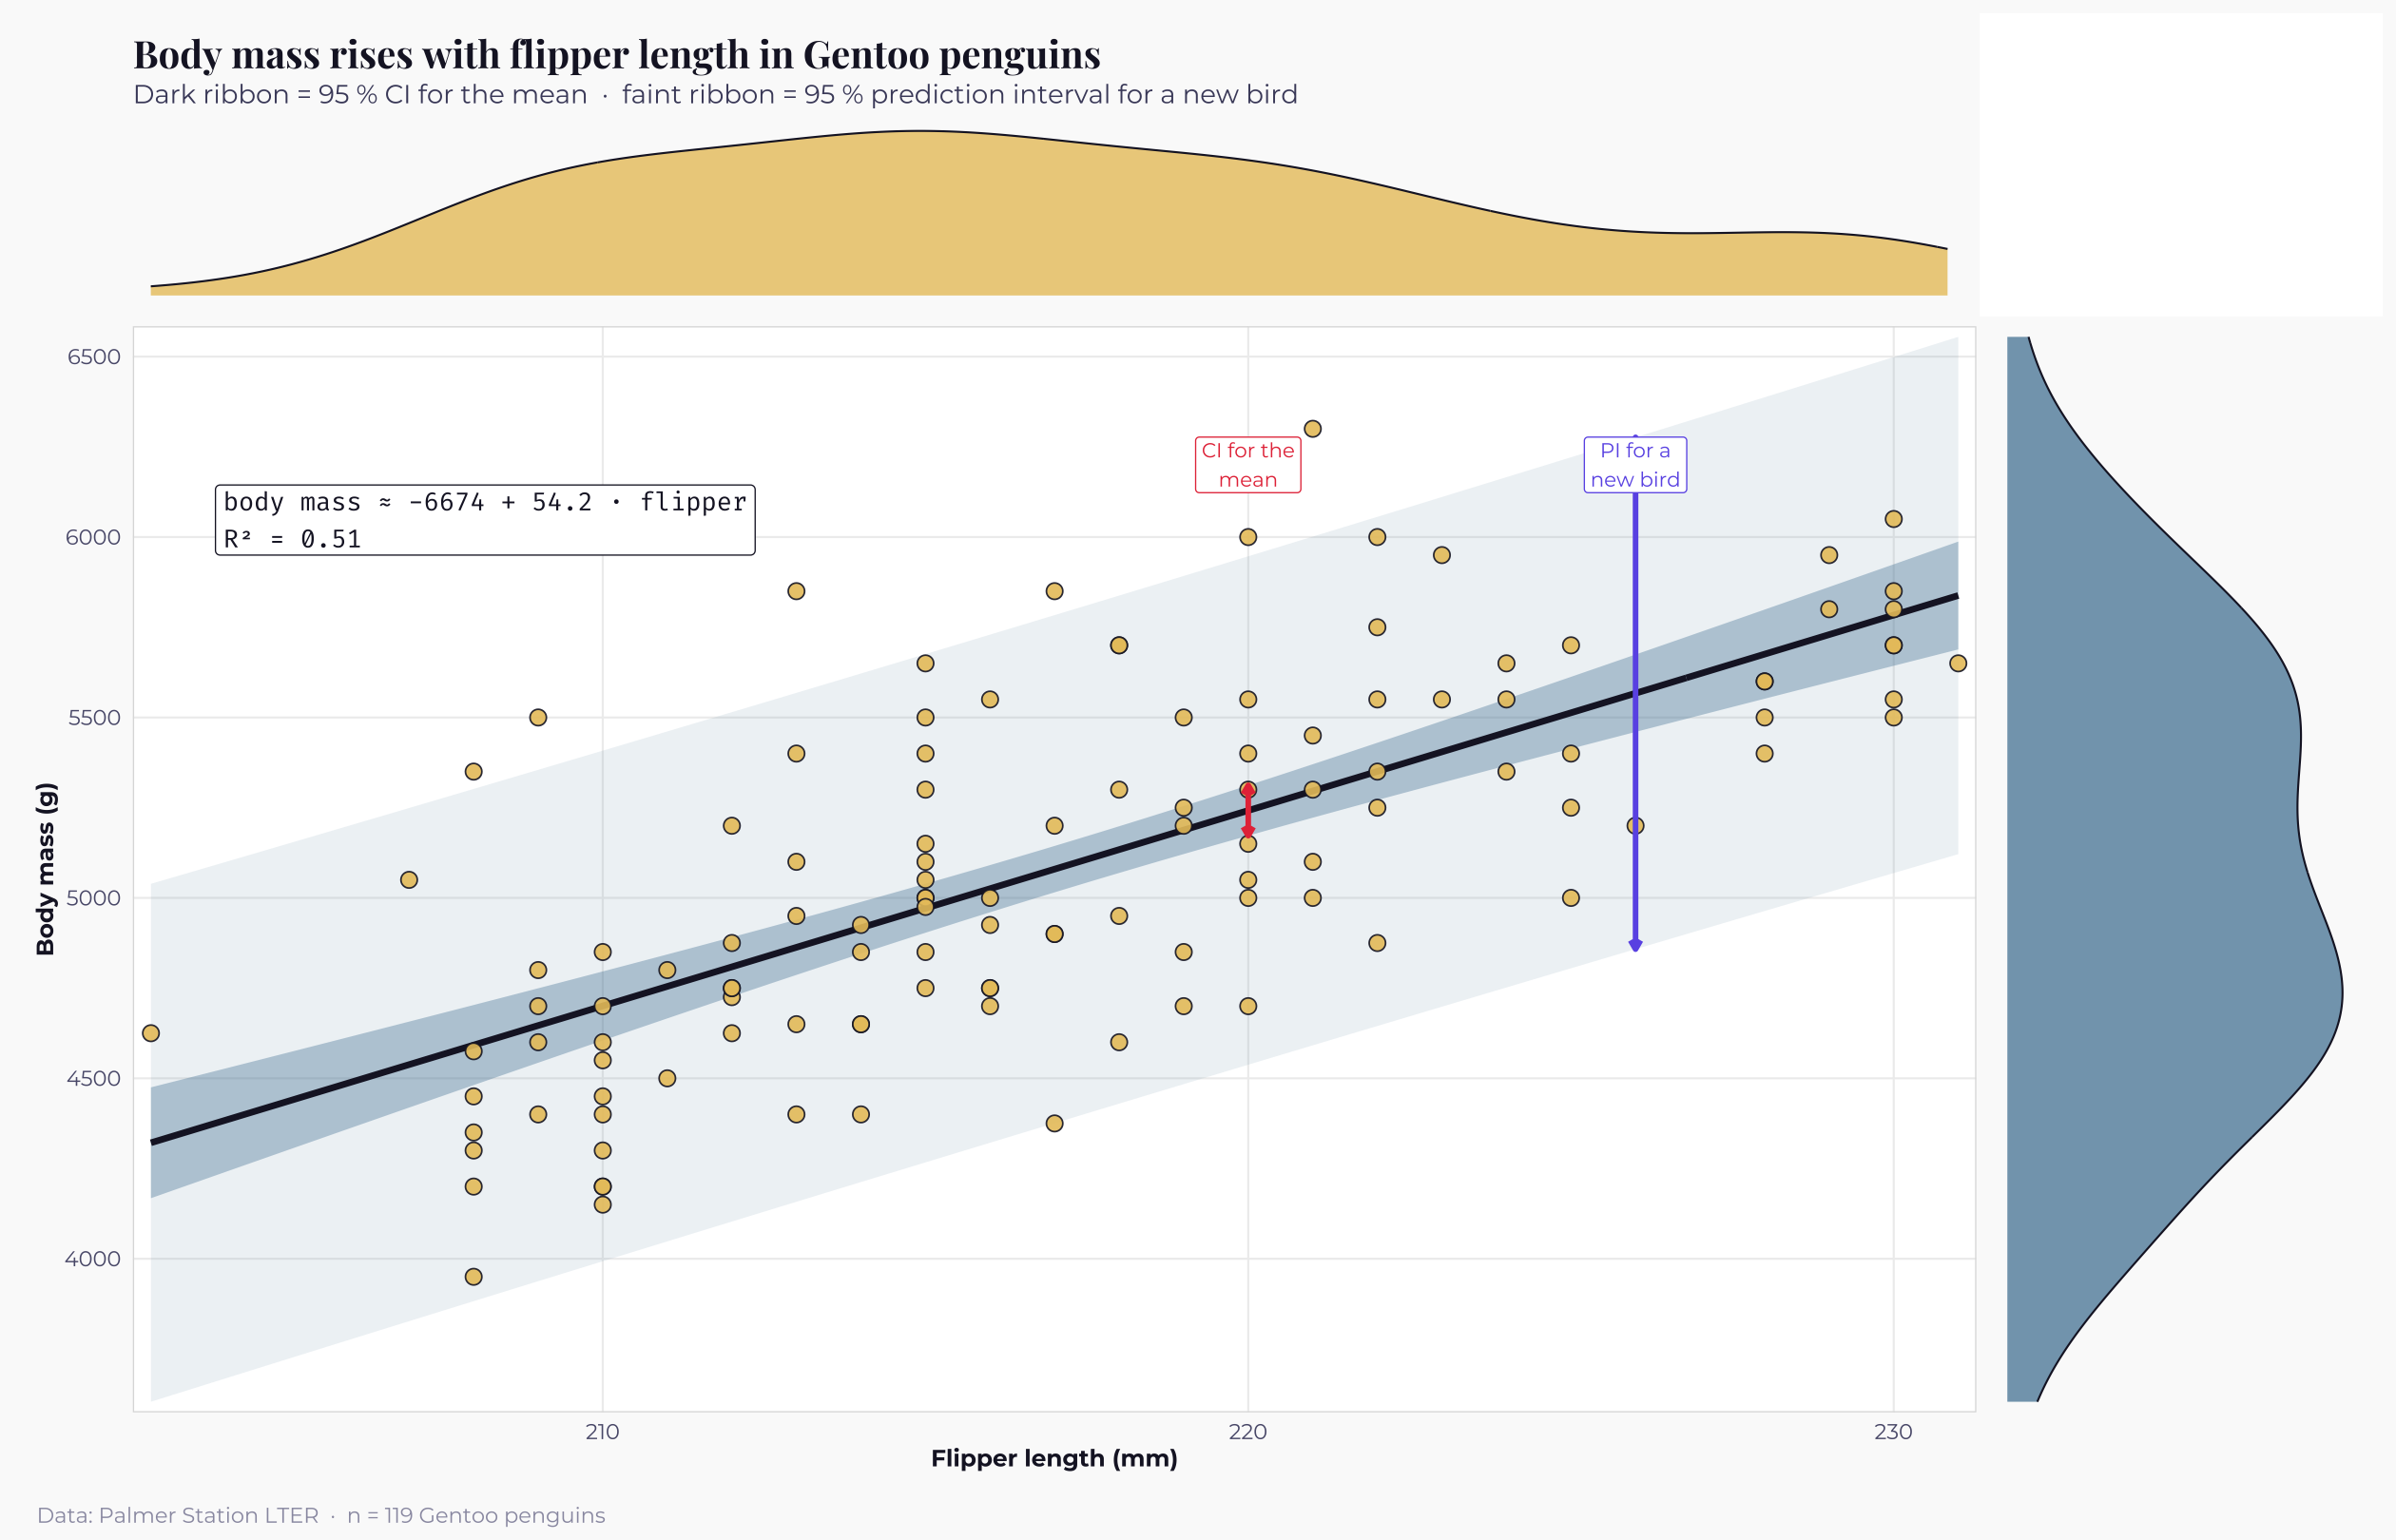

In [12]:
# Assemble all figures
(P_top + plot_spacer() + plot_layout(widths = c(5, 1))) /
  ((P_main | P_right) + plot_layout(widths = c(5, 1))) +
  plot_layout(heights = c(1, 6)) +
  plot_annotation(
    caption = "Data: Palmer Station LTER  \u00b7  n = 119 Gentoo penguins",
    theme = theme(plot.background = element_rect(fill = "#fafafa", colour = NA),
                  plot.caption    = element_text(family = "mont", size = 9,
                                                  colour = "#9a9ab0", hjust = 0)))

Notice how much wider the prediction interval is than the confidence interval. The typical scatter of individual penguins around the mean is several hundred grams; the uncertainty about the mean itself, averaged over many birds, is only a few tens of grams. Reporting a CI where you needed a PI (or vice versa) can lead to dramatically wrong conclusions. If a marine biologist asks you to forecast the body mass of a single captured penguin, you must use the PI; if they ask you about the average body mass in a colony of a thousand, the CI will do.

## Diagnostics — a custom quadrant

Base R gives you four diagnostic plots for free through `plot(fit)`, and they are genuinely useful. They are also unspeakably ugly. We rebuild them here as a single polished quadrant in the house style. Every time you fit a linear model you should stare at these four panels for at least a minute before interpreting a single coefficient. Regression fails quietly: the numbers always come back, and only the diagnostics will tell you when they are meaningless.

The four panels are designed to expose different kinds of failure. The **residuals-versus-fitted** plot tests linearity and reveals nonlinearity as a systematic curve in the LOESS line. The **Q-Q plot of standardised residuals** tests normality; systematic departures from the diagonal suggest heavy tails, skew, or outliers. The **scale-location plot** tests equal variance; the square-root of the absolute standardised residuals should, on average, be flat across fitted values. The **residuals-versus-leverage** plot is the most subtle: it shows which observations are unusual both in *x* and in residual magnitude, with Cook's-distance contours marking the territory where a single point could meaningfully change the fit if it were removed.

In [13]:
library(tidyverse); library(patchwork); library(broom)

aug <- augment(fit) %>%
  mutate(std_resid = .std.resid,
         sqrt_abs  = sqrt(abs(std_resid)))

In [14]:
# residuals vs fitted
D1 <- ggplot(aug, aes(.fitted, .resid)) +
  geom_hline(yintercept = 0, colour = "#1a1a2e", linewidth = 0.4, linetype = "22") +
  geom_point(shape = 21, fill = PalDiscrete[3], colour = "#1a1a2e",
             size = 2.5, stroke = 0.4, alpha = 0.9) +
  geom_smooth(method = "loess", se = FALSE, colour = PalDiscrete[1],
              linewidth = 0.9, formula = y ~ x) +
  labs(title    = "Residuals vs fitted",
       subtitle = "Trend-free scatter around zero = linearity holds",
       x = "Fitted value (g)", y = "Residual (g)") +
  theme_ml()

In [15]:
# Q-Q of standardised residuals
D2 <- ggplot(aug, aes(sample = std_resid)) +
  stat_qq_line(colour = "#1a1a2e", linewidth = 0.5) +
  stat_qq(colour = PalDiscrete[2], size = 2, alpha = 0.85) +
  labs(title    = "Q–Q plot of standardised residuals",
       subtitle = "Points on the line = residuals are normal",
       x = "Theoretical quantile", y = "Standardised residual") +
  theme_ml()

In [16]:
# scale-location
D3 <- ggplot(aug, aes(.fitted, sqrt_abs)) +
  geom_point(shape = 21, fill = PalDiscrete[8], colour = "#1a1a2e",
             size = 2.5, stroke = 0.4, alpha = 0.9) +
  geom_smooth(method = "loess", se = FALSE, colour = PalDiscrete[1],
              linewidth = 0.9, formula = y ~ x) +
  labs(title    = "Scale–location",
       subtitle = "Flat smoother = equal variance across fitted values",
       x = "Fitted value (g)",
       y = expression(sqrt("|standardised residual|"))) +
  theme_ml()

In [17]:
# residuals vs leverage with Cook's distance contours
max_lev <- max(aug$.hat) * 1.05
lev_seq <- seq(0.001, max_lev, length.out = 200)
p <- length(coef(fit))
cook_curves <- expand_grid(h = lev_seq, D = c(0.5, 1)) %>%
  mutate(
    r_pos =  sqrt(D * p * (1 - h) / h),
    r_neg = -sqrt(D * p * (1 - h) / h),
    D_lab = paste0("Cook's D = ", D)
  ) %>% pivot_longer(c(r_pos, r_neg), values_to = "r") %>% drop_na()

D4 <- ggplot(aug, aes(.hat, std_resid)) +
  geom_hline(yintercept = 0, colour = "#1a1a2e", linewidth = 0.35, linetype = "22") +
  geom_line(data = cook_curves, aes(h, r, group = interaction(D_lab, name),
                                    colour = D_lab),
            linewidth = 0.6, linetype = "12") +
  geom_point(aes(size = .cooksd),
             shape = 21, fill = PalDiscrete[5], colour = "#1a1a2e",
             stroke = 0.4, alpha = 0.85) +
  scale_size_continuous(range = c(1.2, 7), name = "Cook's D") +
  scale_colour_manual(values = c("Cook's D = 0.5" = PalDiscrete[2],
                                 "Cook's D = 1"   = PalDiscrete[1]),
                      name = NULL) +
  labs(title    = "Residuals vs leverage",
       subtitle = "Point size = Cook's D  ·  contours mark influential territory",
       x = "Leverage (hat value)", y = "Standardised residual") +
  theme_ml() +
  theme(legend.position = "right")

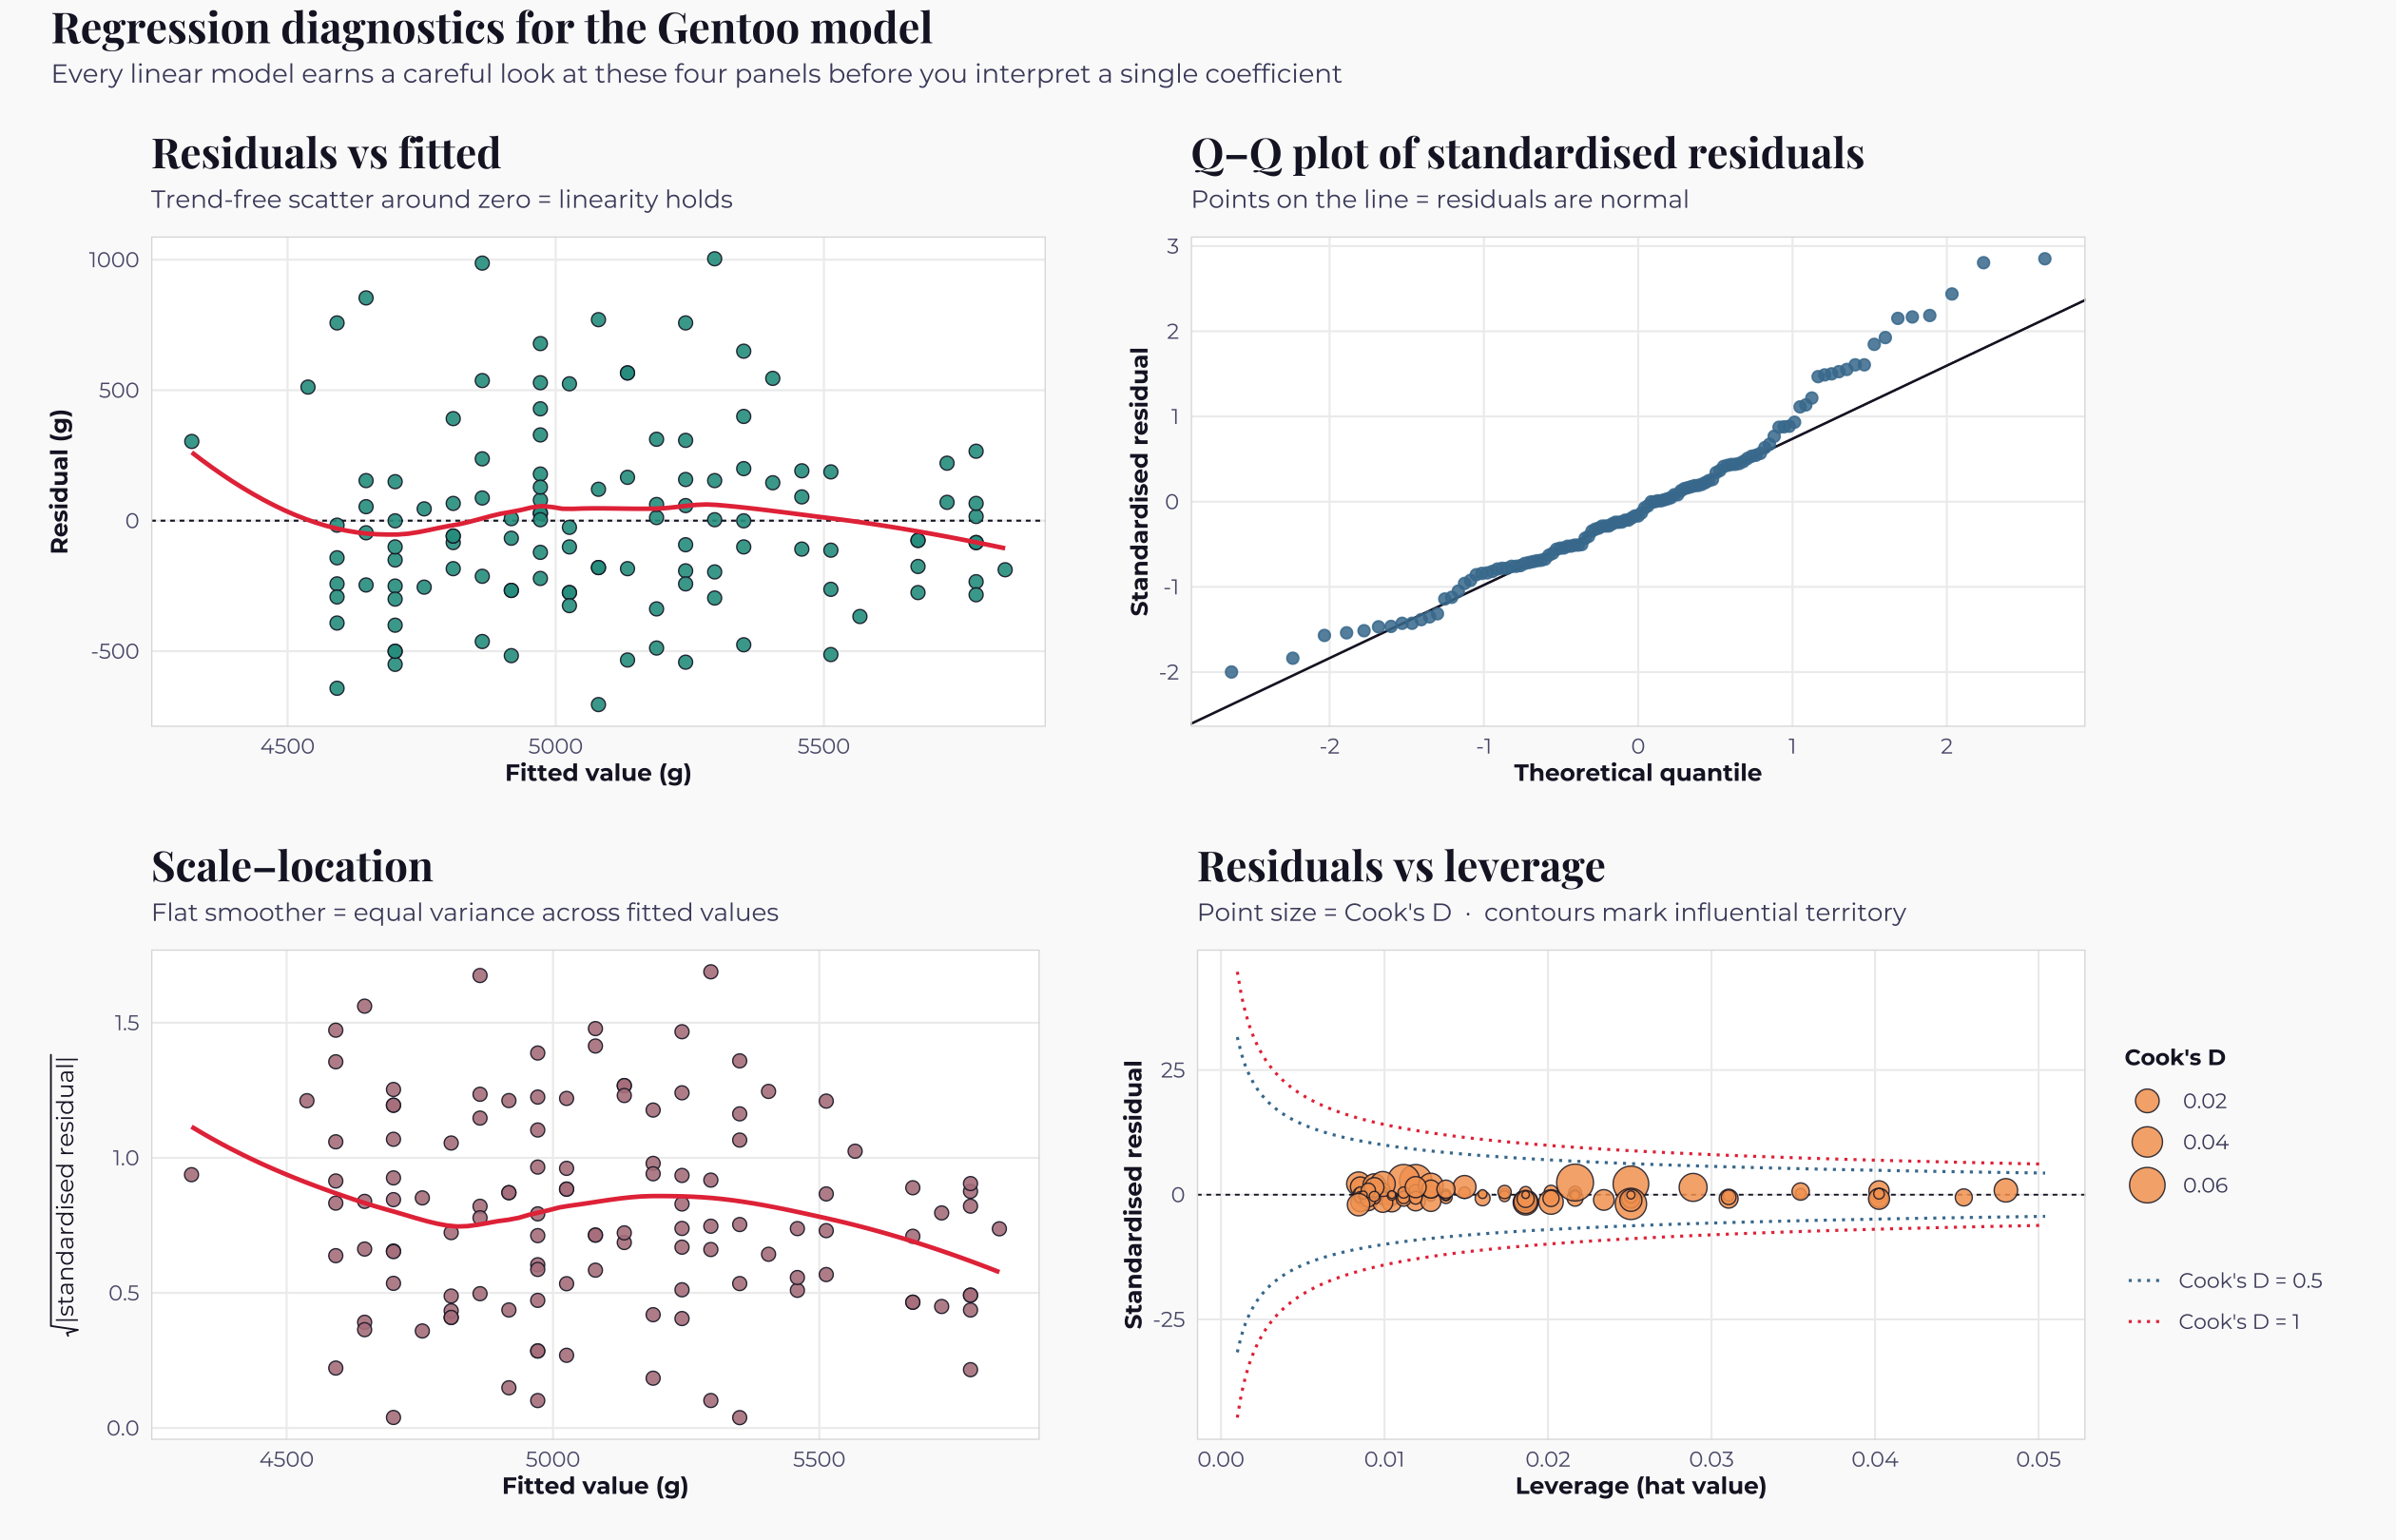

In [18]:
# Assemble all figures
(D1 | D2) / (D3 | D4) +
  plot_annotation(
    title    = "Regression diagnostics for the Gentoo model",
    subtitle = "Every linear model earns a careful look at these four panels before you interpret a single coefficient",
    theme = theme(plot.background = element_rect(fill = "#fafafa", colour = NA),
                  plot.title      = element_text(family = "playfair", face = "bold",
                                                  size = 18, colour = "#1a1a2e"),
                  plot.subtitle   = element_text(family = "mont", size = 11,
                                                  colour = "#4a4a6a")))

For this Gentoo model the diagnostics are genuinely reassuring. The residuals scatter around zero without a systematic trend, the Q-Q plot hugs the diagonal except for one or two points in the tails, the scale-location plot is roughly flat, and no observation approaches a Cook's distance of one. The model is behaving itself. This is, in my experience, rarer than you would hope, and when you do get a clean diagnostic quadrant like this on real data you should enjoy it.

## Influence, leverage, and Cook's distance

The residuals-versus-leverage panel deserves its own section because the concepts it illustrates — leverage and influence — are among the most conceptually important in all of regression diagnostics. **Leverage** measures how unusual an observation's predictor values are, regardless of its response. A penguin with a 250-mm flipper in a sample where everyone else has flippers between 200 and 230 mm has high leverage even if its body mass is exactly what the model would predict. Leverage is purely a property of $x$. **Influence**, in contrast, measures how much the fitted line would change if that observation were removed. An observation can have high leverage but low influence (it sits far out in $x$ but right on the line), low leverage but high influence (it sits near the centre of $x$ but far off the line), or both. Cook's distance $D_i$ combines leverage and residual size into a single scalar measure of influence, and it is the standard diagnostic for identifying observations that might be unduly driving the fit.

The figure below amplifies the residuals-versus-leverage panel and adds a panel showing what happens to the fitted line when we remove the single most influential observation.

In [19]:
library(tidyverse); library(patchwork); library(broom)

most_influential <- aug %>% slice_max(.cooksd, n = 1)

fit_without <- lm(body_mass_g ~ flipper_length_mm,
                  data = gentoo %>% slice(-which.max(aug$.cooksd)))

new_x2 <- tibble(flipper_length_mm = seq(min(gentoo$flipper_length_mm),
                                         max(gentoo$flipper_length_mm),
                                         length.out = 300))
new_x2$with_all <- predict(fit,         newdata = new_x2)
new_x2$without  <- predict(fit_without, newdata = new_x2)

In [20]:
P_main <- ggplot(aug, aes(.hat, std_resid)) +
  geom_hline(yintercept = 0, colour = "#1a1a2e", linewidth = 0.35, linetype = "22") +
  geom_line(data = cook_curves, aes(h, r, group = interaction(D_lab, name),
                                    colour = D_lab),
            linewidth = 0.6, linetype = "12") +
  geom_point(aes(size = .cooksd),
             shape = 21, fill = PalDiscrete[5], colour = "#1a1a2e",
             stroke = 0.4, alpha = 0.85) +
  geom_point(data = most_influential,
             aes(.hat, std_resid, size = .cooksd),
             shape = 21, fill = PalDiscrete[1], colour = "#1a1a2e", stroke = 0.8) +
  scale_size_continuous(range = c(1.3, 8), name = "Cook's D") +
  scale_colour_manual(values = c("Cook's D = 0.5" = PalDiscrete[2],
                                 "Cook's D = 1"   = PalDiscrete[1]),
                      name = NULL) +
  labs(title    = "Which observations are influential?",
       subtitle = "Red point = highest Cook's distance in the Gentoo model",
       x = "Leverage (hat value)", y = "Standardised residual") +
  theme_ml() +
  theme(legend.position = "right")

In [21]:
P_fit <- ggplot(gentoo, aes(flipper_length_mm, body_mass_g)) +
  geom_point(shape = 21, fill = PalDiscrete[4], colour = "#1a1a2e",
             size = 2.4, stroke = 0.4, alpha = 0.85) +
  geom_point(data = gentoo[which.max(aug$.cooksd), , drop = FALSE],
             shape = 21, fill = PalDiscrete[1], colour = "#1a1a2e",
             size = 4, stroke = 0.6) +
  geom_line(data = new_x2, aes(flipper_length_mm, with_all),
            colour = "#1a1a2e", linewidth = 1) +
  geom_line(data = new_x2, aes(flipper_length_mm, without),
            colour = PalDiscrete[1], linewidth = 1, linetype = "22") +
  annotate("label", x = min(gentoo$flipper_length_mm) + 1,
           y = max(gentoo$body_mass_g) - 10,
           label = "solid  = all data\ndashed = without the red point",
           family = "mont", size = 3.2, hjust = 0, vjust = 1,
           fill = "white", colour = "#1a1a2e", label.size = 0.2) +
  labs(title    = "Leave-one-out refit",
       subtitle = "How much does the line actually move?",
       x = "Flipper length (mm)", y = "Body mass (g)") +
  theme_ml()

Warning message in annotate("label", x = min(gentoo$flipper_length_mm) + 1, y = max(gentoo$body_mass_g) - :
“Ignoring unknown parameters: `label.size`”


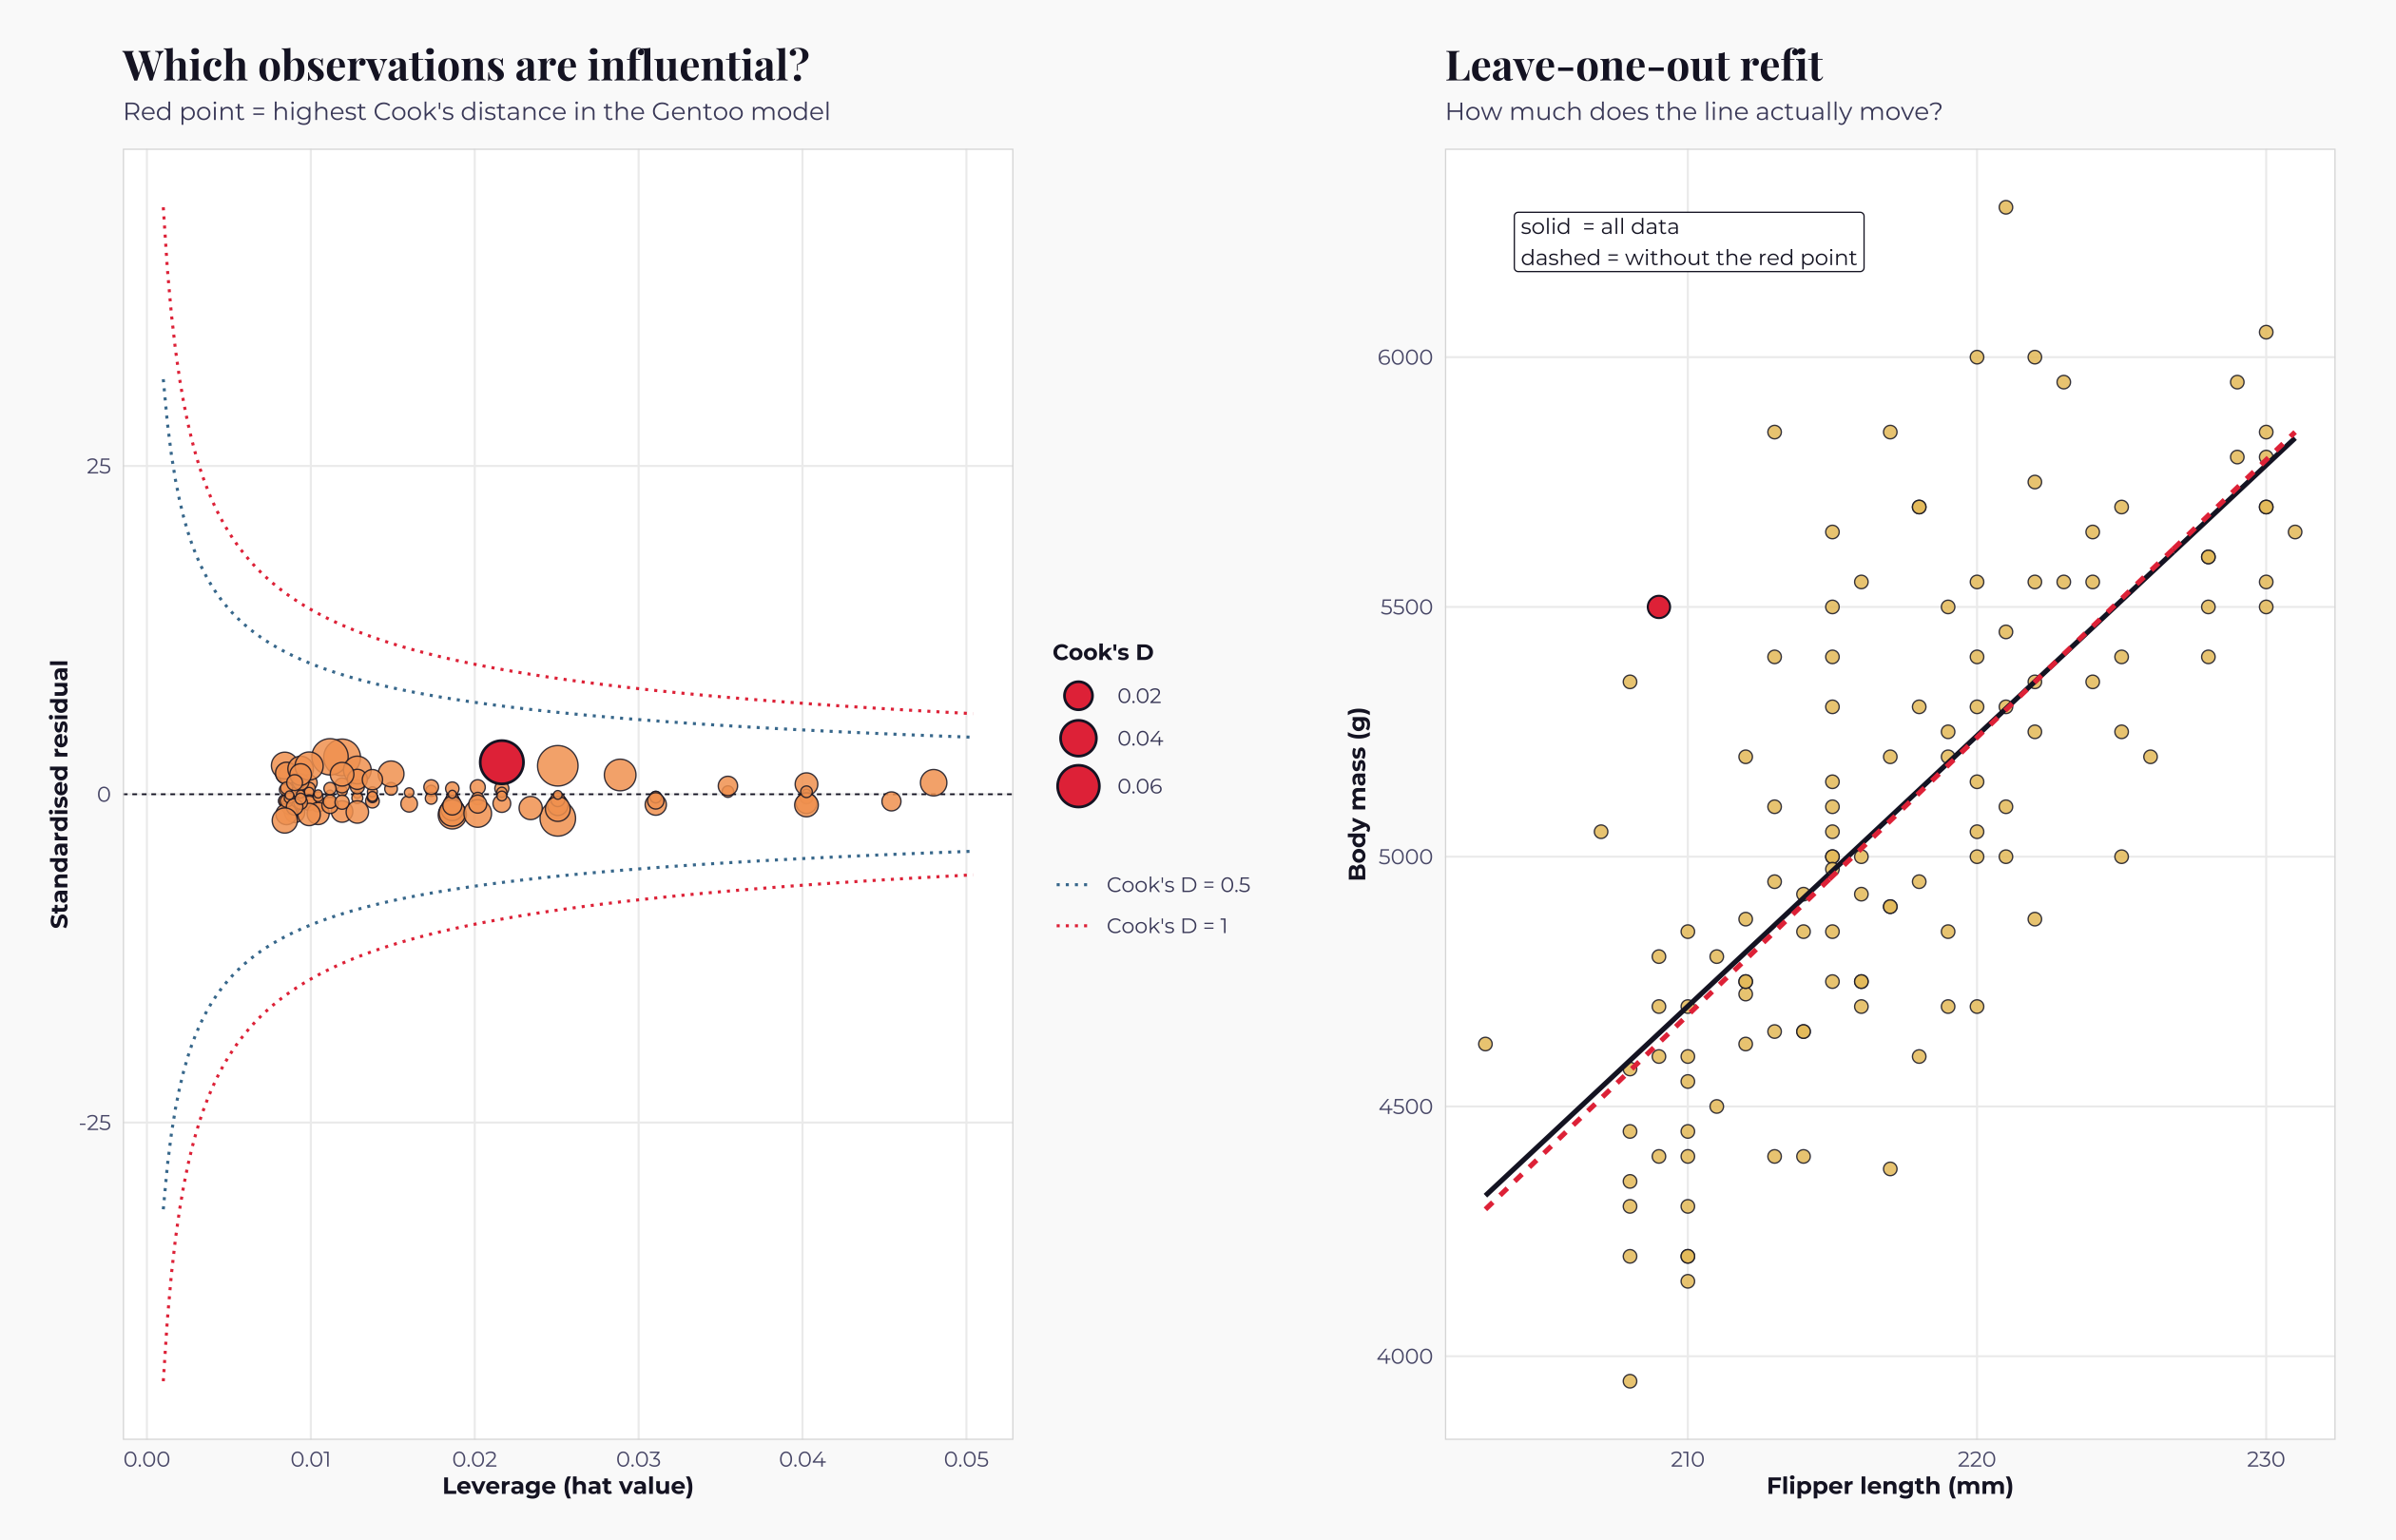

In [22]:
(P_main | P_fit) +
  plot_annotation(
    theme = theme(plot.background = element_rect(fill = "#fafafa", colour = NA)))

In this case, removing the most-influential observation shifts the fitted line by almost nothing — which is exactly the outcome we want. A commonly cited rule of thumb is that observations with Cook's distance greater than one deserve a closer look, and observations with $D_i > 4/n$ deserve at least a glance. Neither threshold is magic. The correct response to an influential observation is almost never to delete it, but to investigate: was it mis-measured? mis-identified? from a different population? If the data point is legitimate, it is telling you something real about the tail of the distribution and deleting it would be dishonest.

## Multiple regression — adding predictors

In practice, one predictor is rarely enough. We know from Part 01 that Gentoo penguin body mass varies with sex, and probably with season and island. The **multiple linear regression** model generalises the simple regression equation to any number of predictors:

$$
y_i \;=\; \beta_0 \;+\; \beta_1 x_{1i} \;+\; \beta_2 x_{2i} \;+\; \ldots \;+\; \beta_p x_{pi} \;+\; \varepsilon_i.
$$

Each coefficient $\beta_j$ now has a subtly different interpretation from the one-predictor case: it is the expected change in $y$ associated with a one-unit increase in $x_j$, *holding all other predictors fixed*. The phrase *"holding all other predictors fixed"* does a lot of work and is worth pausing on. It is what allows us to talk about the effect of flipper length while *controlling for* the effect of sex. But it is also what lets confounding and multicollinearity do their mischief: if two predictors are so tightly correlated that you cannot, in your sample, find two observations that differ in one without also differing in the other, then you cannot estimate their effects separately.

Let us add sex to our Gentoo model. Since `sex` is categorical, R will encode it as a dummy variable — `0` for one level and `1` for the other — and the coefficient will represent the difference between levels.

In [23]:
fit2 <- lm(body_mass_g ~ flipper_length_mm + sex, data = gentoo)
tidy(fit2, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), \(z) signif(z, 4)))

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-318.7,1112.000,-0.2866,7.749e-01,-2521.00,1884.00
flipper_length_mm,23.5,5.225,4.4970,1.642e-05,13.15,33.85
sexmale,597.5,68.550,8.7160,2.375e-14,461.70,733.30


In [24]:
glance(fit2) %>%
  select(r.squared, adj.r.squared, sigma, statistic, p.value) %>%
  mutate(across(where(is.numeric), \(z) signif(z, 4)))

r.squared,adj.r.squared,sigma,statistic,p.value
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.7015,0.6963,276.3,136.3,3.544e-31



Two things have changed. The coefficient for flipper length has shifted slightly — it is now the within-sex slope, controlling for the fact that males tend both to have longer flippers and to be heavier. The sex coefficient tells us that, holding flipper length constant, male Gentoos are on average about five hundred grams heavier than females. And the model's R² has jumped dramatically: adding sex has nearly doubled the fraction of variation we can explain. Visually, the model corresponds to two parallel lines, one per sex, sharing the same slope but offset vertically.


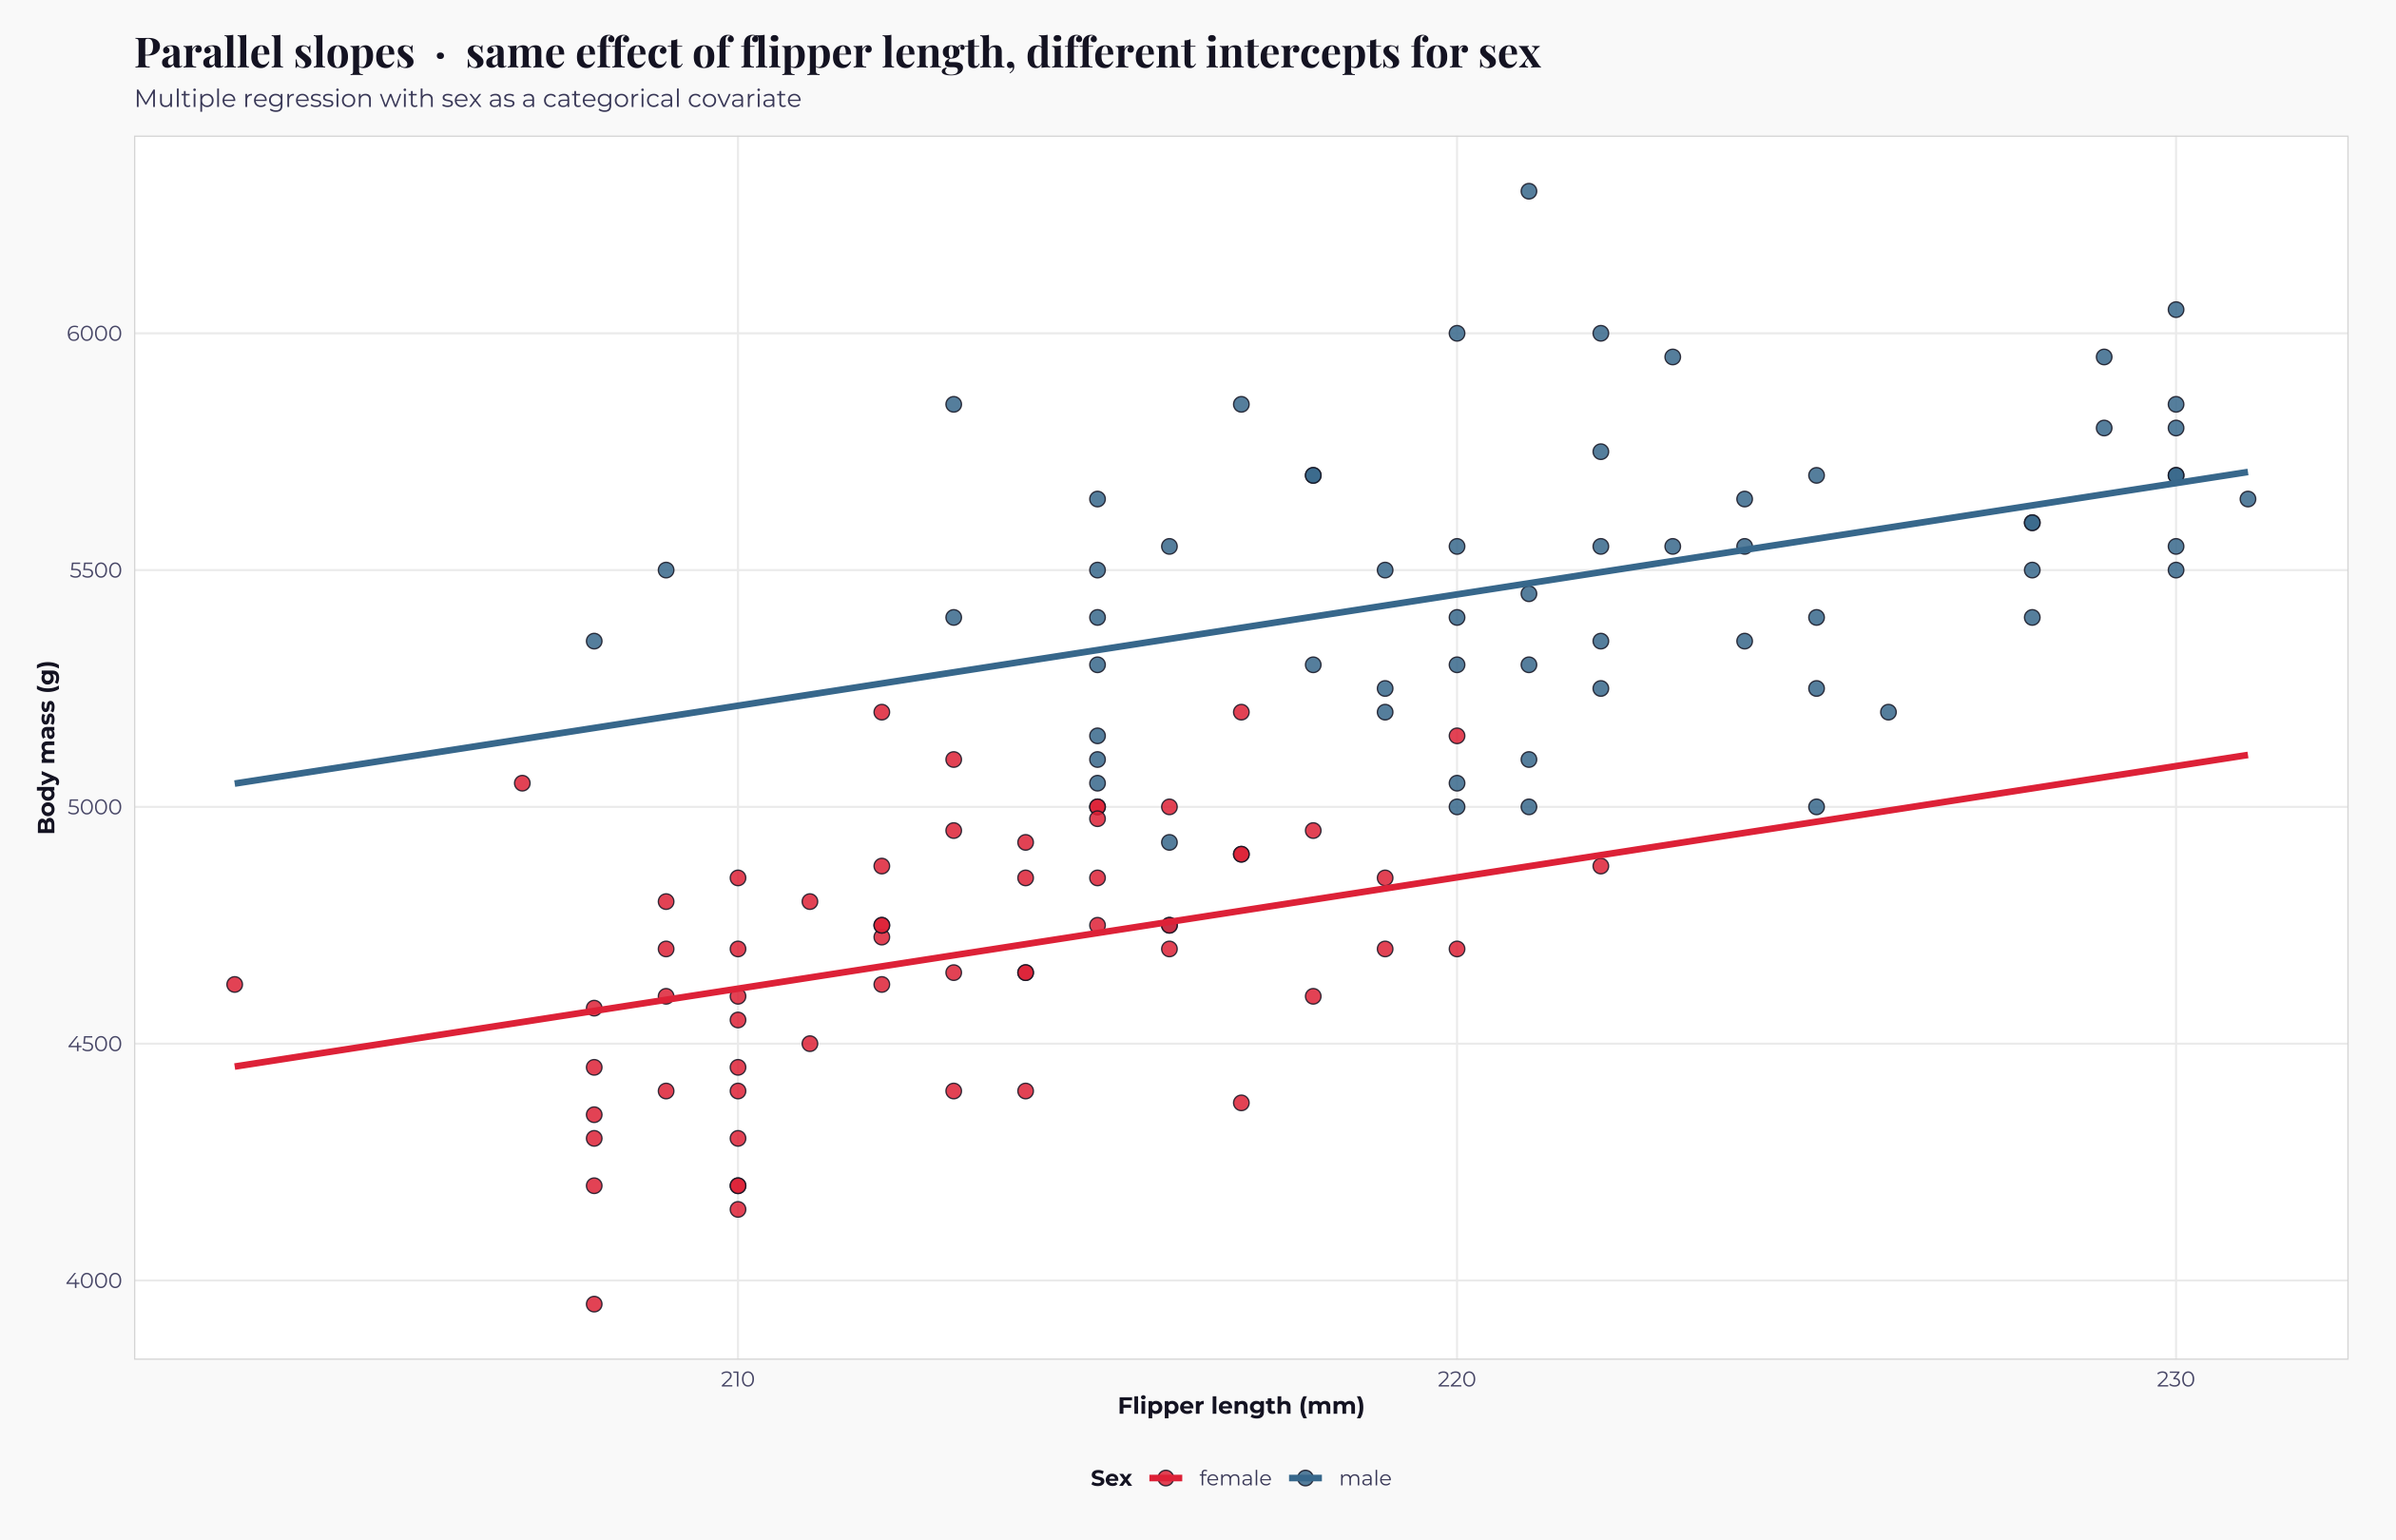

In [25]:
new_grid <- expand_grid(
  flipper_length_mm = seq(min(gentoo$flipper_length_mm),
                          max(gentoo$flipper_length_mm), length.out = 200),
  sex = c("female", "male")
)
new_grid$pred <- predict(fit2, newdata = new_grid)

ggplot(gentoo, aes(flipper_length_mm, body_mass_g, colour = sex, fill = sex)) +
  geom_point(shape = 21, size = 2.8, stroke = 0.4, alpha = 0.85,
             colour = "#1a1a2e") +
  geom_line(data = new_grid, aes(y = pred), linewidth = 1.3) +
  scale_fill_manual  (values = c("female" = PalDiscrete[1], "male" = PalDiscrete[2]),
                      name = "Sex") +
  scale_colour_manual(values = c("female" = PalDiscrete[1], "male" = PalDiscrete[2]),
                      name = "Sex") +
  labs(title    = "Parallel slopes  ·  same effect of flipper length, different intercepts for sex",
       subtitle = "Multiple regression with sex as a categorical covariate",
       x = "Flipper length (mm)", y = "Body mass (g)") +
  theme_ml()

### Interactions — when slopes differ between groups

The parallel-slopes assumption we just imposed is a testable one. Perhaps male Gentoos not only have different intercepts from females, but a genuinely different rate of increase of mass with flipper length. To test this, we add an **interaction term** to the model, written in R with a colon (`flipper_length_mm:sex`) or, more conveniently, using the `*` operator, which expands to the main effects plus the interaction:

In [26]:
fit3 <- lm(body_mass_g ~ flipper_length_mm * sex, data = gentoo)
tidy(fit3, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), \(z) signif(z, 4)))

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-2813.00,1987.000,-1.416,0.1595000,-6748.00,1123.000
flipper_length_mm,35.23,9.339,3.772,0.0002577,16.73,53.720
sexmale,4257.00,2422.000,1.757,0.0815500,-541.80,9055.000
flipper_length_mm:sexmale,-16.98,11.240,-1.511,0.1335000,-39.25,5.279


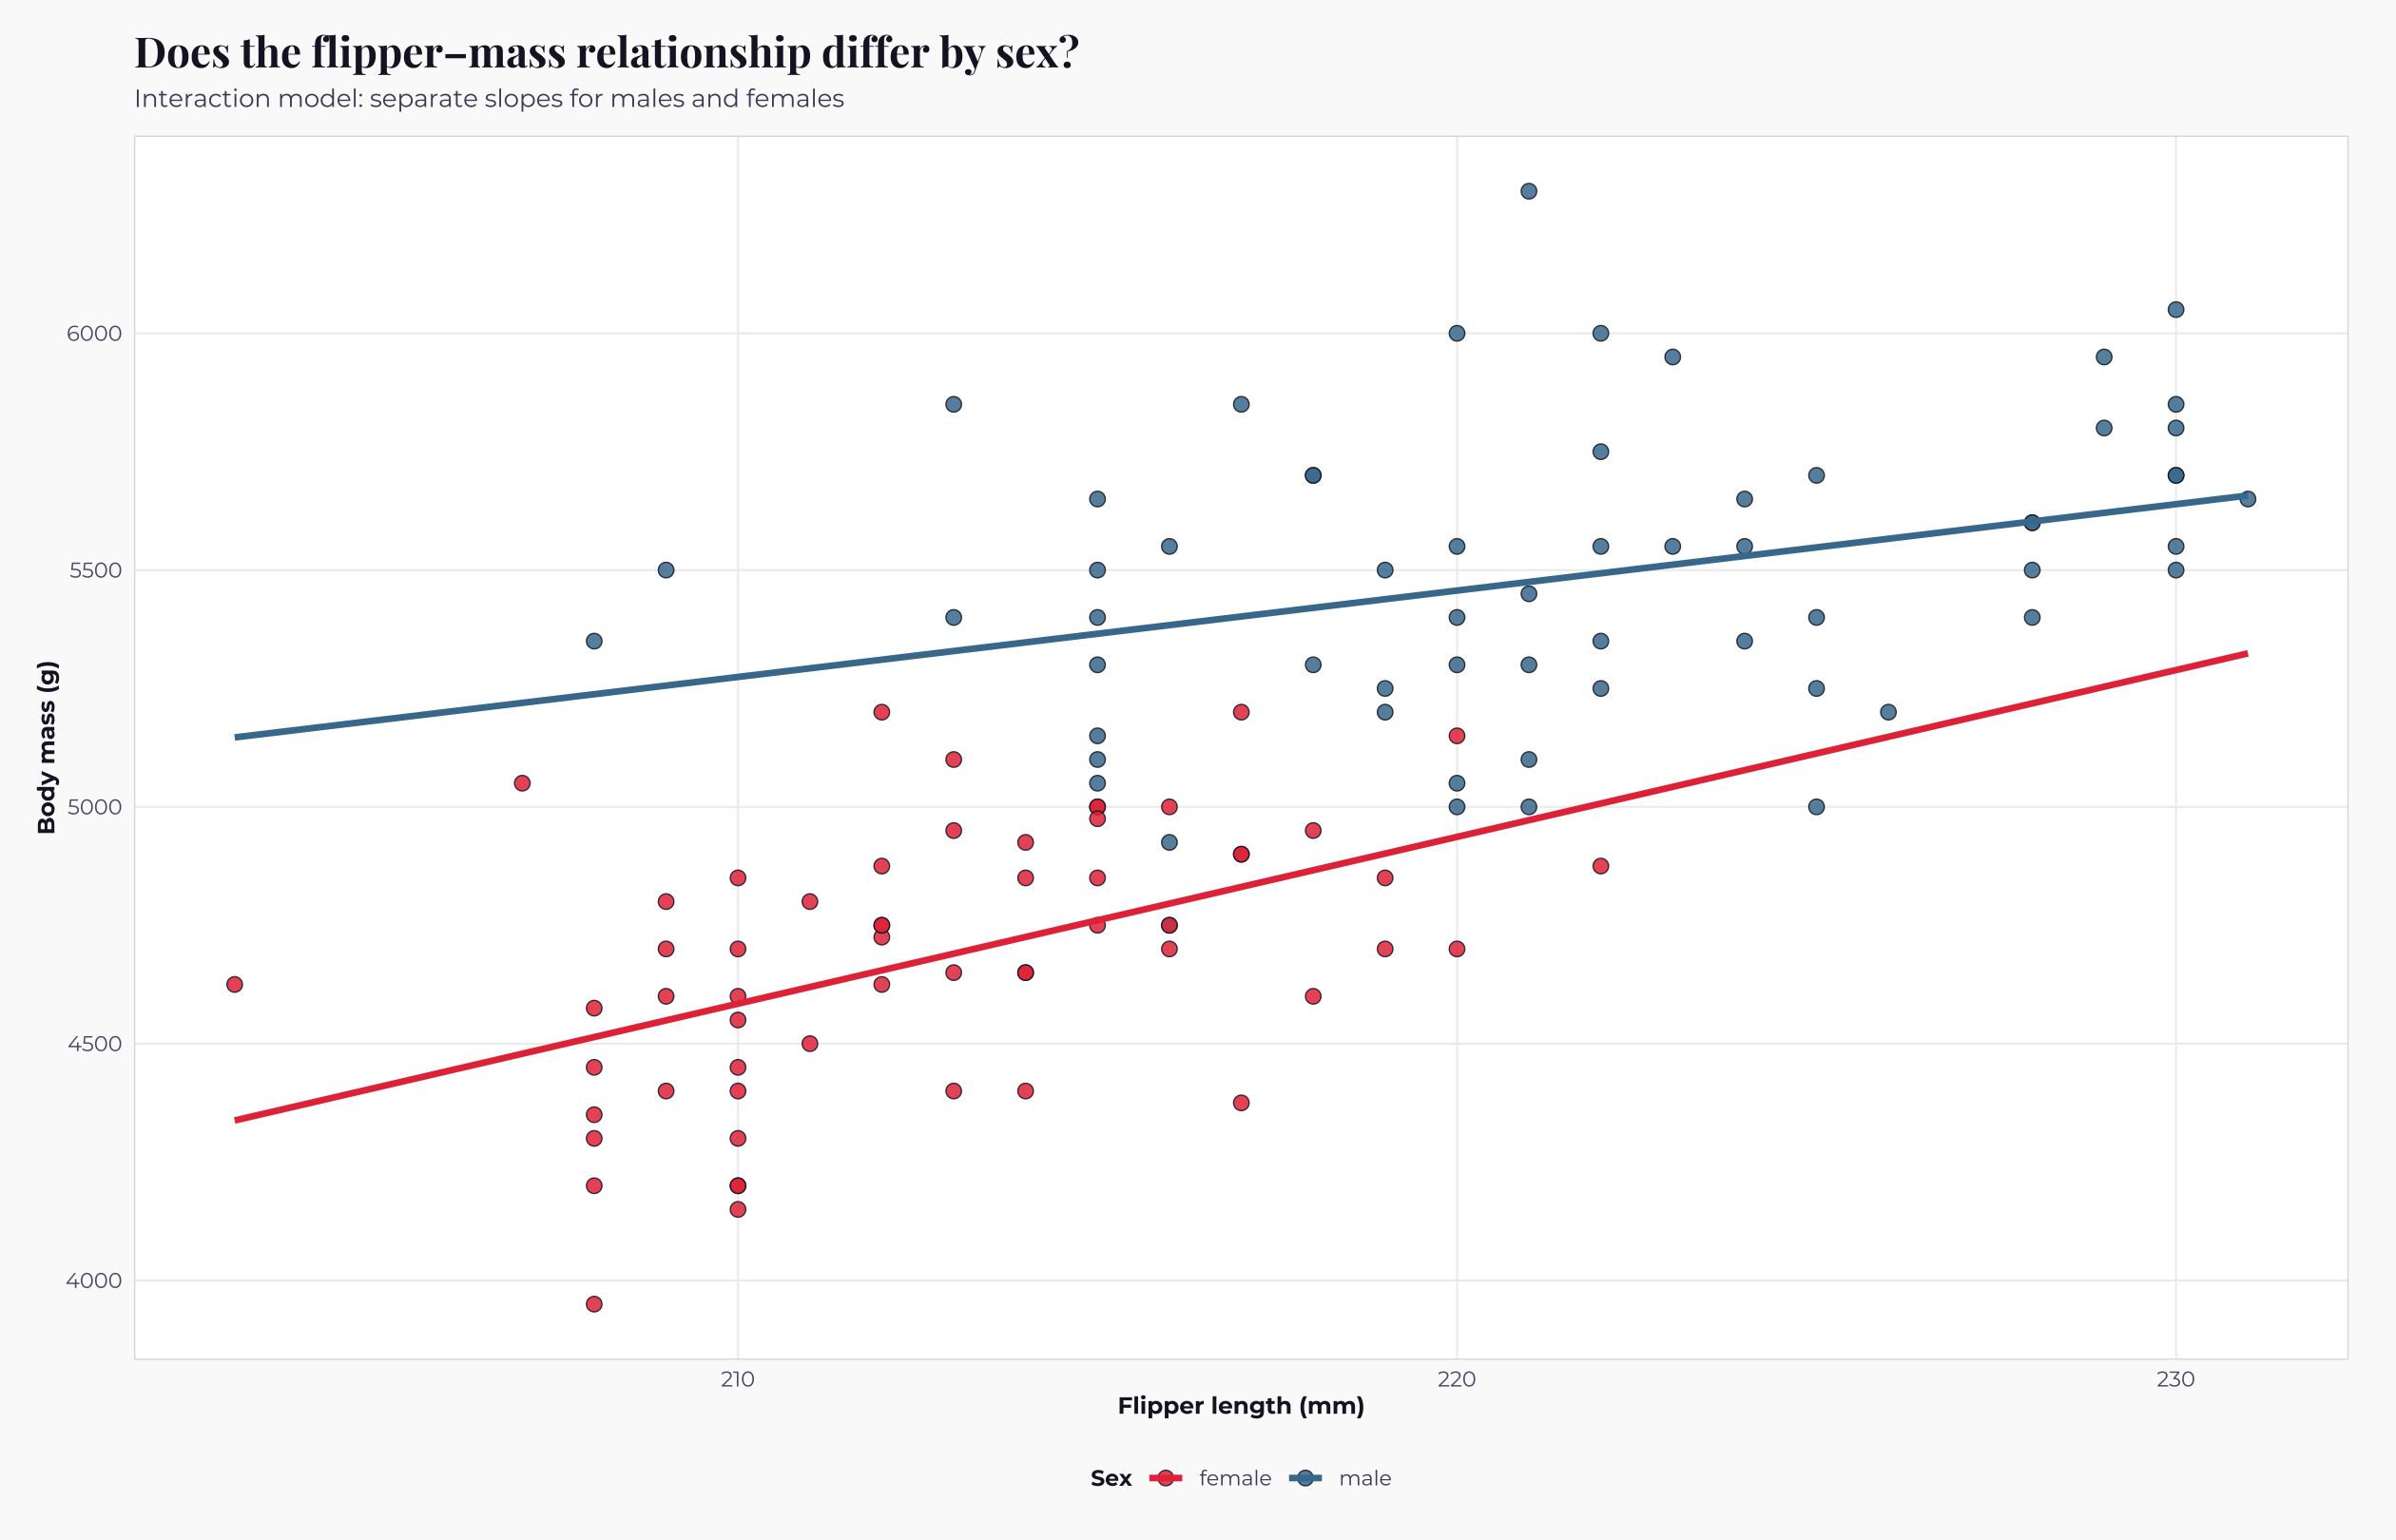

In [27]:
grid3 <- expand_grid(
  flipper_length_mm = seq(min(gentoo$flipper_length_mm),
                          max(gentoo$flipper_length_mm), length.out = 200),
  sex = c("female", "male")
)
grid3$pred <- predict(fit3, newdata = grid3)

ggplot(gentoo, aes(flipper_length_mm, body_mass_g, colour = sex, fill = sex)) +
  geom_point(shape = 21, size = 2.8, stroke = 0.4, alpha = 0.85,
             colour = "#1a1a2e") +
  geom_line(data = grid3, aes(y = pred), linewidth = 1.3) +
  scale_fill_manual  (values = c("female" = PalDiscrete[1], "male" = PalDiscrete[2]),
                      name = "Sex") +
  scale_colour_manual(values = c("female" = PalDiscrete[1], "male" = PalDiscrete[2]),
                      name = "Sex") +
  labs(title    = "Does the flipper–mass relationship differ by sex?",
       subtitle = "Interaction model: separate slopes for males and females",
       x = "Flipper length (mm)", y = "Body mass (g)") +
  theme_ml()


The interaction coefficient tests whether the two slopes differ. If it is small and non-significant — as it is in this case — we have no evidence against the parallel-slopes model and should usually prefer the simpler `fit2`. If it had been large and significant, we would conclude that the relationship between flipper length and mass genuinely differs between the sexes, which would itself be a biologically interesting finding. The general principle here, often called the *principle of parsimony* or **Occam's razor** in statistics, is to prefer the simpler model when the data do not support the more complex one.


## Uncertainty via the bootstrap

Every coefficient we have estimated comes with a standard error, and those standard errors are constructed under specific distributional assumptions. When the assumptions hold, the standard errors are exact and the confidence intervals are correctly calibrated. When they do not — when residuals are skewed, or heteroscedastic, or heavy-tailed — the parametric standard errors can be systematically wrong. One elegant and remarkably robust alternative is the **nonparametric bootstrap**, a method introduced by Bradley Efron in 1979 that changed applied statistics permanently.

The bootstrap's core idea is this: if we had the luxury of drawing many independent samples from the population, we could estimate the coefficient in each sample and the spread of those estimates would *be* the sampling distribution. We do not have that luxury — we have just one sample. But we can simulate the procedure by resampling *with replacement* from our observed data: draw $n$ observations, with replacement, from the $n$ we have; fit the model to the resampled data; record the coefficient. Repeat several thousand times and the spread of the recorded coefficients gives a direct, nonparametric estimate of their sampling distribution. No assumptions about residual distribution needed, no algebra required.

The figure below visualises the full bootstrap distribution of the fitted line — five hundred bootstrap fits overlaid, with the point-estimate fit drawn in bold over the top. The resulting "fan" gives a direct visual sense of how much the line could have varied had we drawn a slightly different sample.

In [28]:
set.seed(2024)
library(tidyverse); library(patchwork)

B <- 500
boot_lines <- map_dfr(seq_len(B), function(b) {
  idx <- sample.int(nrow(gentoo), replace = TRUE)
  mod_b <- lm(body_mass_g ~ flipper_length_mm, data = gentoo[idx, ])
  tibble(
    rep = b,
    flipper_length_mm = new_x$flipper_length_mm,
    y = predict(mod_b, newdata = new_x)
  )
})

In [29]:
boot_coefs <- map_dfr(seq_len(B), function(b) {
  idx <- sample.int(nrow(gentoo), replace = TRUE)
  mod_b <- lm(body_mass_g ~ flipper_length_mm, data = gentoo[idx, ])
  tibble(
    rep       = b,
    intercept = coef(mod_b)[1],
    slope     = coef(mod_b)[2]
  )
})

In [30]:
point_line <- tibble(
  flipper_length_mm = new_x$flipper_length_mm,
  y = predict(fit, newdata = new_x)
)

In [31]:
# Quantile bands from the bootstrap lines — a "fan" with concentric CIs
boot_bands <- boot_lines %>%
  group_by(flipper_length_mm) %>%
  summarise(
    q025 = quantile(y, 0.025),
    q100 = quantile(y, 0.10),
    q250 = quantile(y, 0.25),
    q500 = quantile(y, 0.50),
    q750 = quantile(y, 0.75),
    q900 = quantile(y, 0.90),
    q975 = quantile(y, 0.975),
    .groups = "drop"
  )

In [32]:
# Panel A: the fan, built from nested quantile ribbons
P_fan <- ggplot() +
  geom_ribbon(data = boot_bands,
              aes(flipper_length_mm, ymin = q025, ymax = q975),
              fill = PalDiscrete[2], alpha = 0.15) +
  geom_ribbon(data = boot_bands,
              aes(flipper_length_mm, ymin = q100, ymax = q900),
              fill = PalDiscrete[2], alpha = 0.25) +
  geom_ribbon(data = boot_bands,
              aes(flipper_length_mm, ymin = q250, ymax = q750),
              fill = PalDiscrete[2], alpha = 0.40) +
  geom_line(data = boot_lines %>% filter(rep %in% sample.int(B, 40)),
            aes(flipper_length_mm, y, group = rep),
            colour = PalDiscrete[2], linewidth = 0.22, alpha = 0.35) +
  geom_line(data = boot_bands, aes(flipper_length_mm, q500),
            colour = PalDiscrete[7], linewidth = 0.8, linetype = "22") +
  geom_line(data = point_line, aes(flipper_length_mm, y),
            colour = "#1a1a2e", linewidth = 1.4) +
  geom_point(data = gentoo, aes(flipper_length_mm, body_mass_g),
             shape = 21, fill = PalDiscrete[4], colour = "#1a1a2e",
             size = 2.4, stroke = 0.4, alpha = 0.85) +
  labs(title    = "The bootstrap fan  \u00b7  nested 50 / 80 / 95 % bands",
       subtitle = "Dark line = OLS point estimate  \u00b7  dashed = bootstrap median  \u00b7  faint wisps = individual fits",
       x = "Flipper length (mm)", y = "Body mass (g)") +
  theme_ml()

In [33]:
# Panel B: joint distribution of (intercept, slope)
P_joint <- ggplot(boot_coefs, aes(intercept, slope)) +
  stat_density_2d(aes(fill = after_stat(density)),
                  geom = "raster", contour = FALSE, n = 150) +
  scale_fill_gradientn(colours = c("#ffffff", "#f0e9d4", "#fdd49e", "#fc8d59",
                                   "#d7301f", "#7f0000"),
                       guide = "none") +
  geom_density_2d(colour = "#1a1a2e", linewidth = 0.3, alpha = 0.5, bins = 6) +
  geom_hline(yintercept = coef(fit)[2], colour = PalDiscrete[7],
             linewidth = 0.5, linetype = "22") +
  geom_vline(xintercept = coef(fit)[1], colour = PalDiscrete[7],
             linewidth = 0.5, linetype = "22") +
  annotate("point", x = coef(fit)[1], y = coef(fit)[2],
           shape = 4, size = 5, stroke = 1.8, colour = "#1a1a2e") +
  annotate("label", x = coef(fit)[1], y = coef(fit)[2] + 2.5,
           label = "OLS estimate", family = "mont", fontface = "bold",
           size = 3.0, colour = "#1a1a2e", fill = "#ffffff",
           label.size = 0.2) +
  labs(title    = "Joint bootstrap distribution",
       subtitle = "Negative \u03b2\u02c60\u2013\u03b2\u02c61 correlation (elongated cloud)",
       x = expression(Intercept ~ hat(beta)[0]),
       y = expression(Slope ~ hat(beta)[1])) +
  theme_ml() +
  theme(plot.title    = element_text(size = 12),
        plot.subtitle = element_text(size = 9))

Warning message in annotate("label", x = coef(fit)[1], y = coef(fit)[2] + 2.5, label = "OLS estimate", :
“Ignoring unknown parameters: `label.size`”


In [34]:
# Panel C: marginal slope histogram
P_slope <- ggplot(boot_coefs, aes(slope)) +
  geom_histogram(fill = PalDiscrete[2], colour = "#1a1a2e",
                 linewidth = 0.2, bins = 30, alpha = 0.9) +
  geom_vline(xintercept = coef(fit)[2],
             colour = PalDiscrete[1], linewidth = 1) +
  geom_vline(xintercept = quantile(boot_coefs$slope, c(0.025, 0.975)),
             colour = PalDiscrete[7], linewidth = 0.6, linetype = "22") +
  labs(title    = "Bootstrap slope distribution",
       subtitle = "Red = OLS estimate  \u00b7  dashed = 95 % CI",
       x = "Slope (g / mm)", y = "Count") +
  theme_ml() +
  theme(plot.title    = element_text(size = 12),
        plot.subtitle = element_text(size = 9))

In [35]:
# Panel D: marginal intercept histogram
P_int <- ggplot(boot_coefs, aes(intercept)) +
  geom_histogram(fill = PalDiscrete[3], colour = "#1a1a2e",
                 linewidth = 0.2, bins = 30, alpha = 0.9) +
  geom_vline(xintercept = coef(fit)[1],
             colour = PalDiscrete[1], linewidth = 1) +
  geom_vline(xintercept = quantile(boot_coefs$intercept, c(0.025, 0.975)),
             colour = PalDiscrete[7], linewidth = 0.6, linetype = "22") +
  labs(title    = "Bootstrap intercept distribution",
       subtitle = "Spread reflects sampling variability",
       x = "Intercept (g)", y = "Count") +
  theme_ml() +
  theme(plot.title    = element_text(size = 12),
        plot.subtitle = element_text(size = 9))

In [36]:
cat("\nBootstrap 95% percentile CIs:\n")
cat(sprintf("  Slope     : [%.2f, %.2f]\n",
            quantile(boot_coefs$slope, 0.025),
            quantile(boot_coefs$slope, 0.975)))
cat(sprintf("  Intercept : [%.0f, %.0f]\n",
            quantile(boot_coefs$intercept, 0.025),
            quantile(boot_coefs$intercept, 0.975)))


Bootstrap 95% percentile CIs:
  Slope     : [46.35, 63.56]
  Intercept : [-8715, -4933]


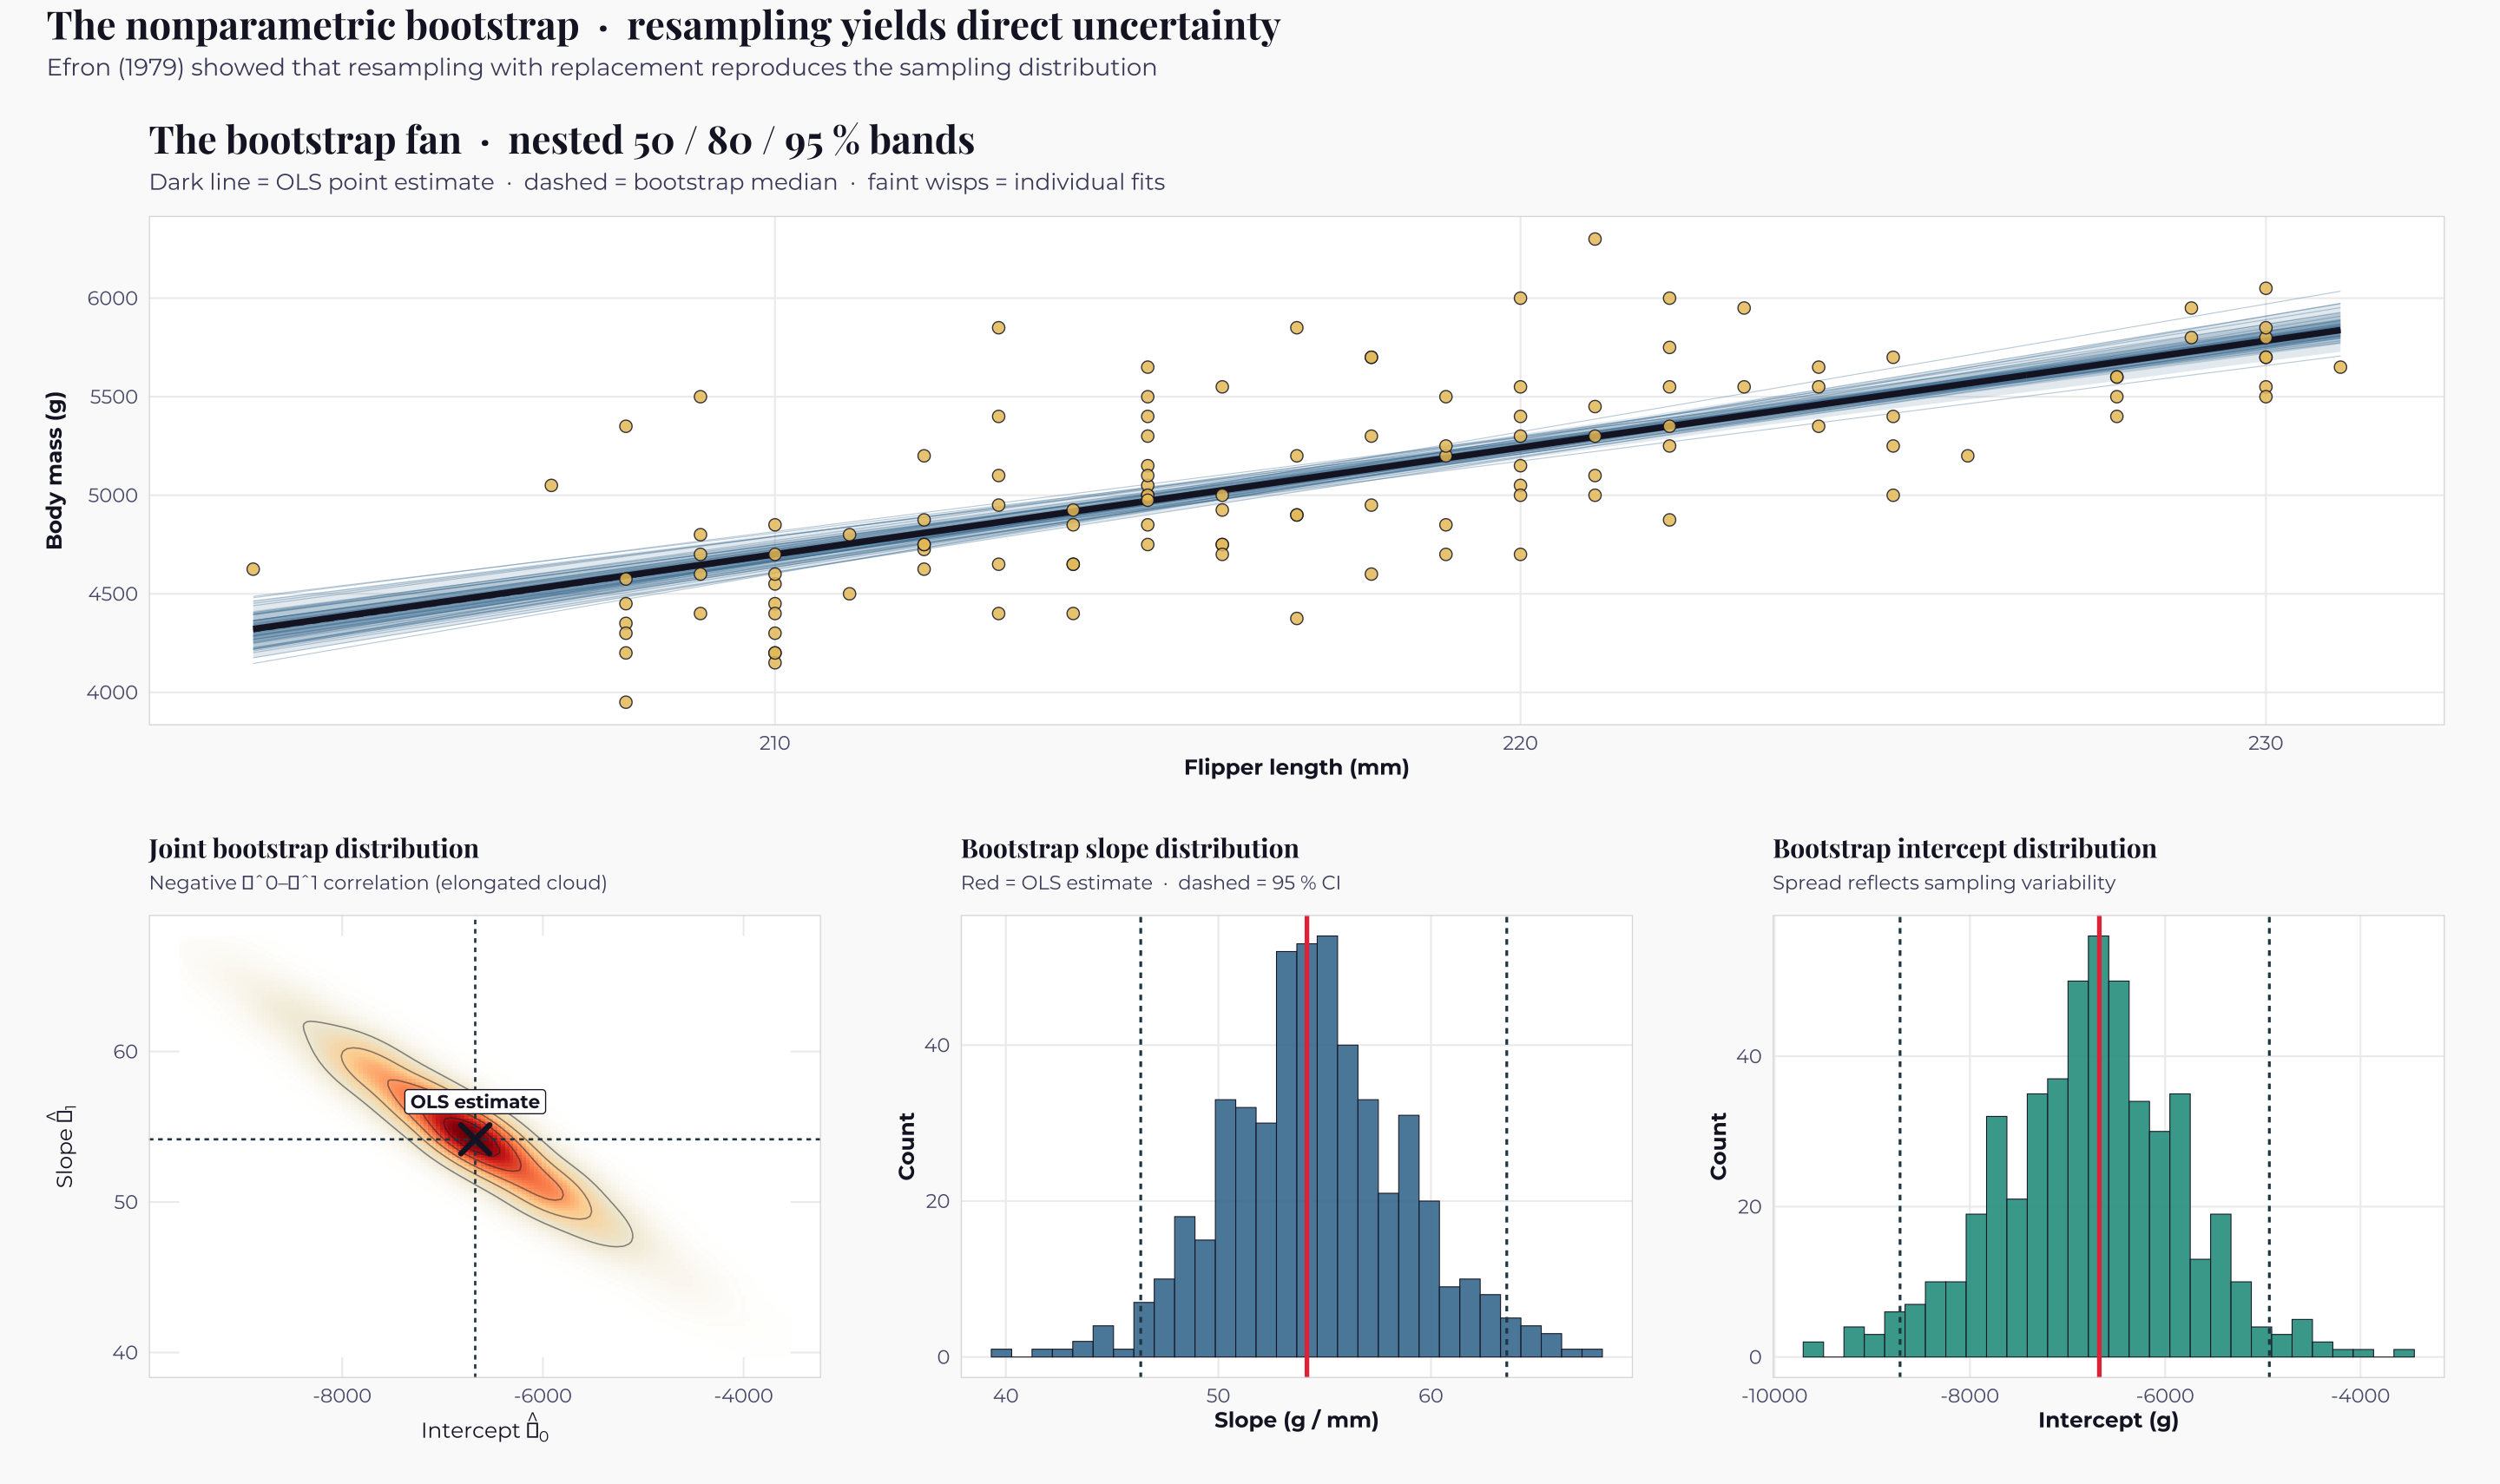

In [37]:
# Compose: fan on top spanning full width, three panels below with extra width
options(repr.plot.width = 16, repr.plot.height = 9.5)
P_fan / (P_joint | P_slope | P_int) +
  plot_layout(heights = c(1.1, 1)) +
  plot_annotation(
    title    = "The nonparametric bootstrap  \u00b7  resampling yields direct uncertainty",
    subtitle = "Efron (1979) showed that resampling with replacement reproduces the sampling distribution",
    theme = theme(plot.background = element_rect(fill = "#fafafa", colour = NA),
                  plot.title      = element_text(family = "playfair", face = "bold",
                                                  size = 18, colour = "#1a1a2e"),
                  plot.subtitle   = element_text(family = "mont", size = 11,
                                                  colour = "#4a4a6a")))

Compare these percentile intervals to the parametric ones reported by `confint(fit)`. For this well-behaved Gentoo dataset they agree closely, which is the expected outcome when the assumptions hold. When they disagree — as they often do on skewed or heteroscedastic data — the bootstrap intervals are usually the ones worth trusting, because they carry no parametric assumptions that could be violated.

## Predictive evaluation — honest assessment on held-out data

Every measure of fit we have computed so far has been calculated on the same data used to fit the model. This is *in-sample* performance, and it is systematically optimistic: a flexible model can always achieve perfect in-sample fit by memorising the training data, but such a model generalises appallingly. To estimate how well the model will behave on new data, we must evaluate it on data it has never seen. The simplest version of this is a single **train/test split**.

We split the Gentoo dataset into a training portion (roughly 70 %) and a test portion (roughly 30 %), fit the model on the training data only, and evaluate its predictions against the test data's known values using metrics that live on the response scale.

In [38]:
set.seed(2026)
idx   <- sample(seq_len(nrow(gentoo)), size = floor(0.7 * nrow(gentoo)))
train <- gentoo[idx,  ]
test  <- gentoo[-idx, ]

fit_train <- lm(body_mass_g ~ flipper_length_mm + sex, data = train)

test_pred <- predict(fit_train, newdata = test)
test_residual <- test$body_mass_g - test_pred

rmse <- sqrt(mean(test_residual^2))
mae  <- mean(abs(test_residual))
oos_r2 <- 1 - sum(test_residual^2) /
               sum((test$body_mass_g - mean(test$body_mass_g))^2)

cat(sprintf("Test-set RMSE          : %.1f g\n", rmse))
cat(sprintf("Test-set MAE           : %.1f g\n", mae))
cat(sprintf("Out-of-sample R²       : %.3f\n", oos_r2))
cat(sprintf("In-sample R² (for comparison): %.3f\n",
            summary(fit_train)$r.squared))

Test-set RMSE          : 292.0 g
Test-set MAE           : 216.1 g
Out-of-sample R²       : 0.648
In-sample R² (for comparison): 0.719


Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour
values.”


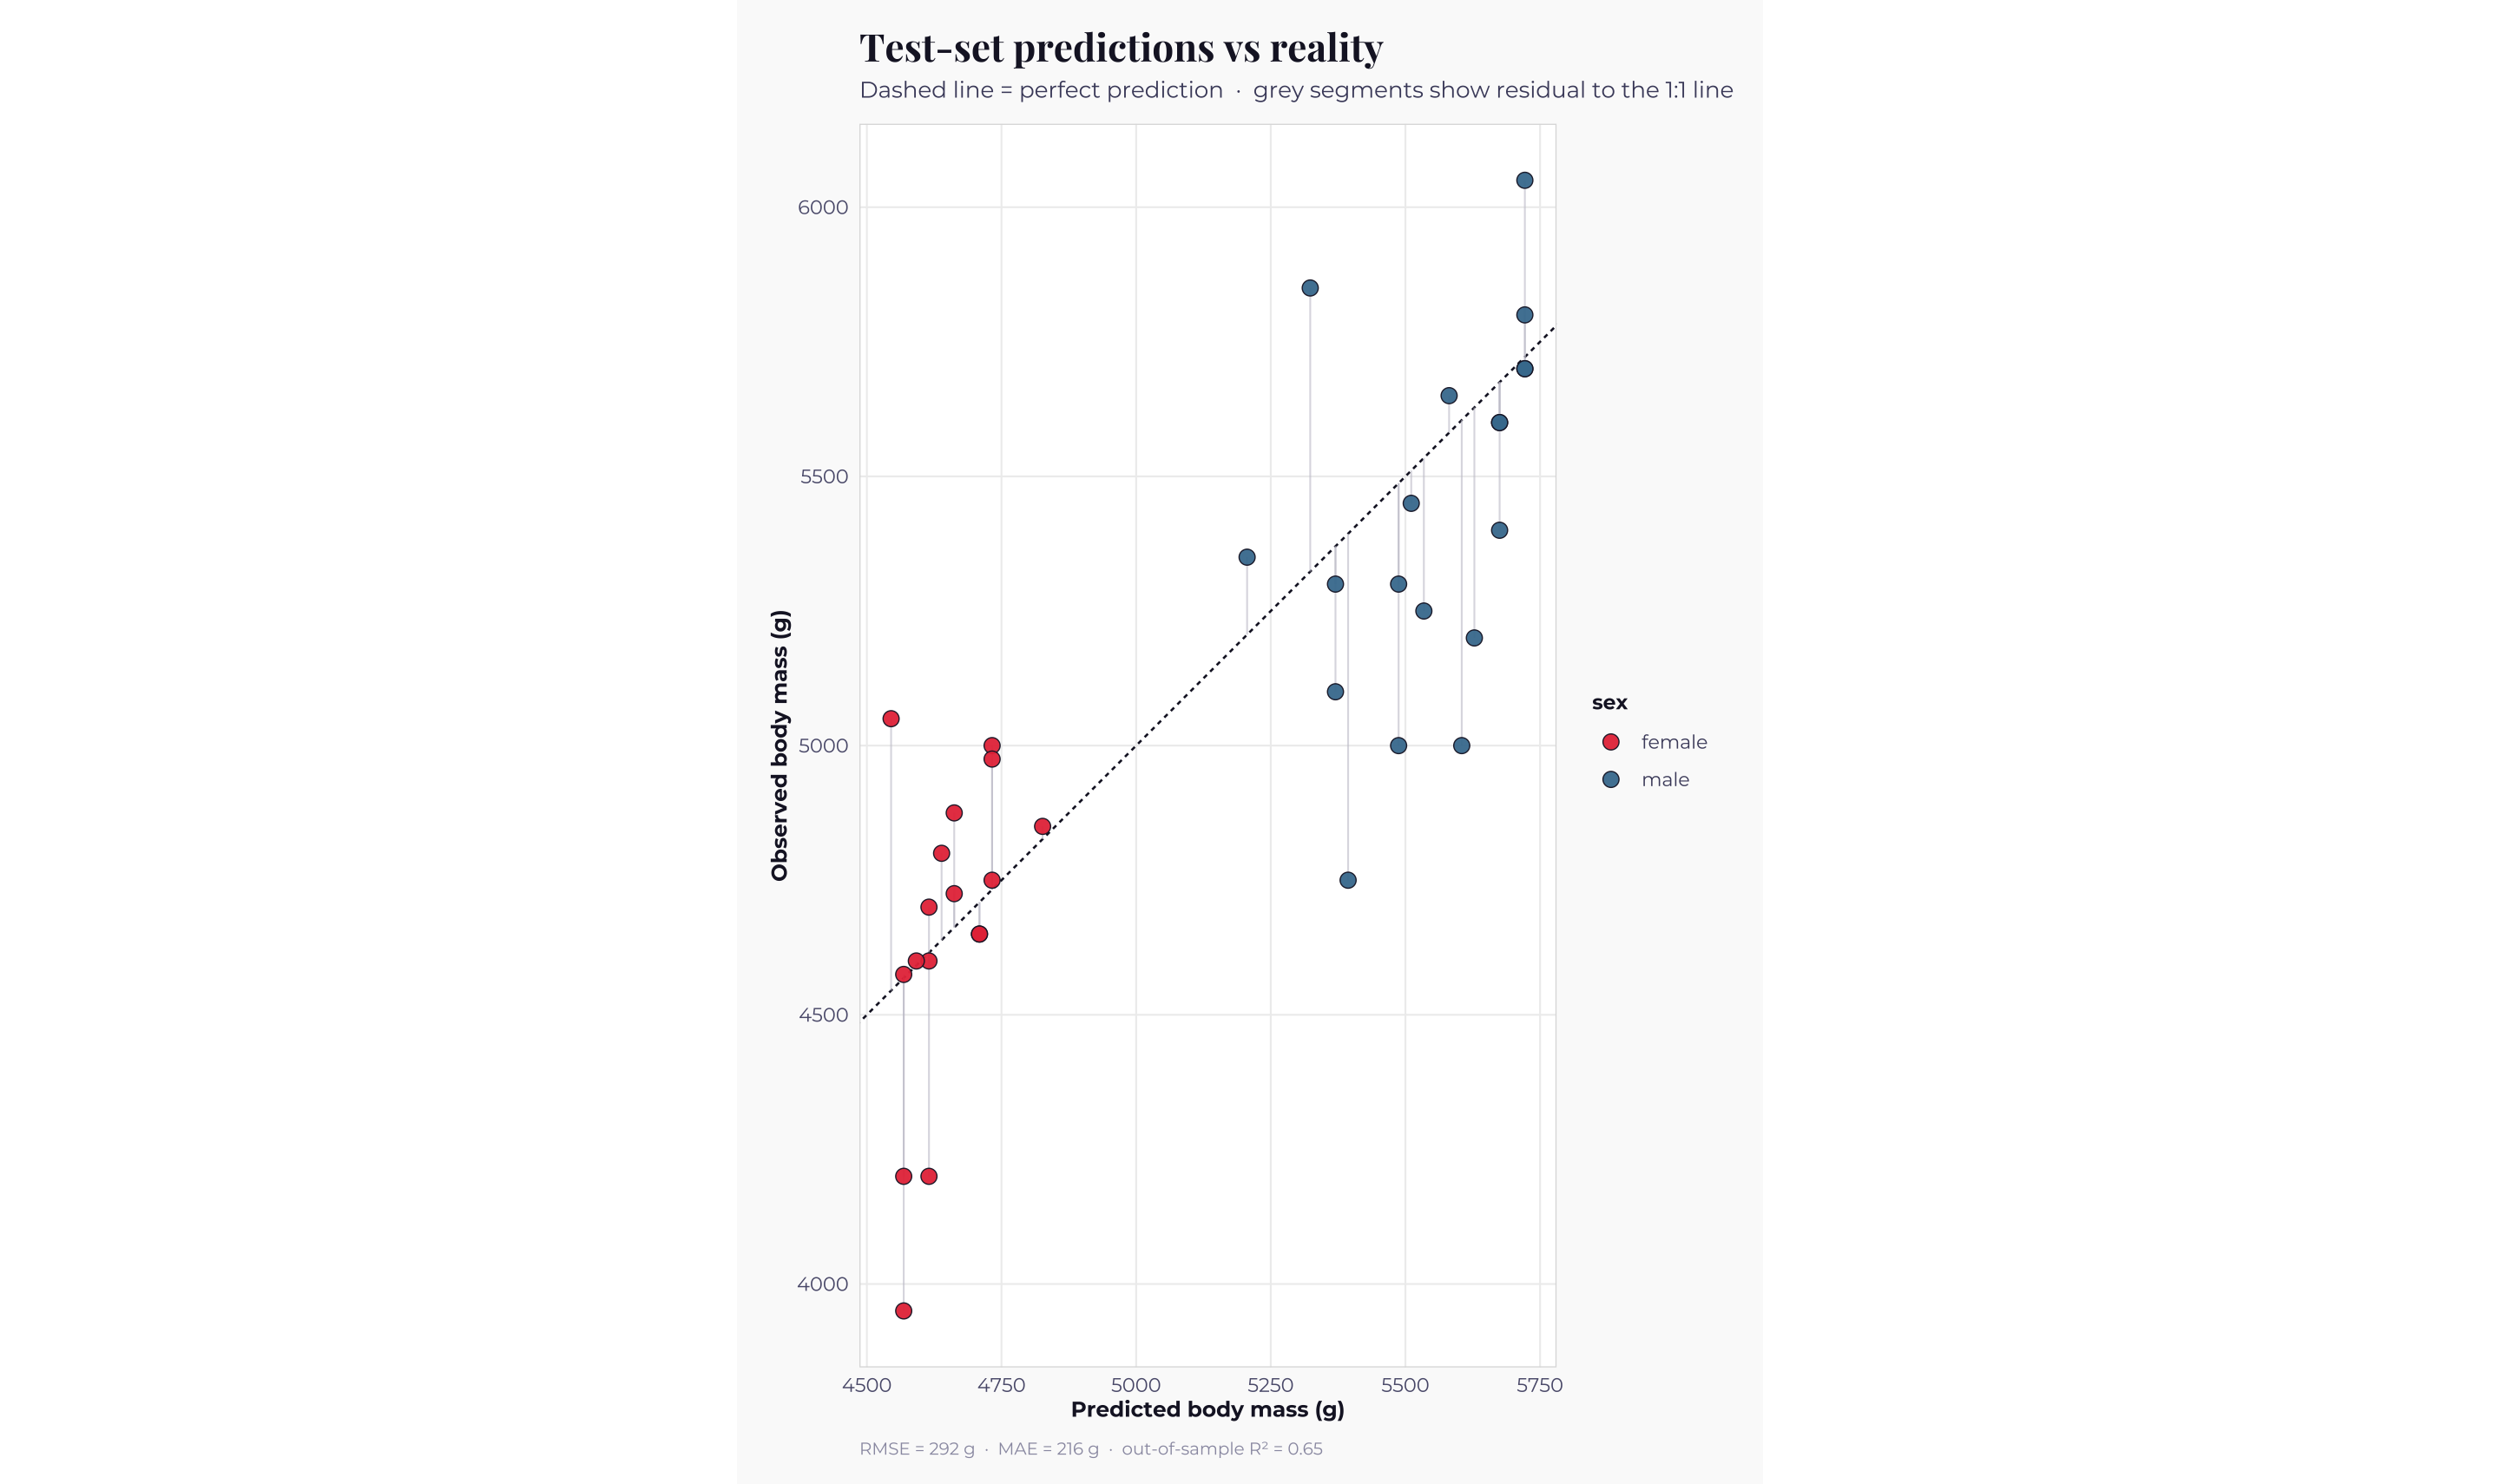

In [39]:
test_aug <- test %>% mutate(pred = test_pred, resid = body_mass_g - pred)

ggplot(test_aug, aes(pred, body_mass_g, colour = sex, fill = sex)) +
  geom_abline(slope = 1, intercept = 0,
              colour = "#1a1a2e", linetype = "22", linewidth = 0.5) +
  geom_segment(aes(xend = pred, yend = pred),
               colour = "#c5c5d0", linewidth = 0.4, alpha = 0.6) +
  geom_point(shape = 21, size = 3.2, stroke = 0.4, alpha = 0.95,
             colour = "#1a1a2e") +
  scale_fill_manual  (values = c("female" = PalDiscrete[1], "male" = PalDiscrete[2])) +
  scale_colour_manual(values = c("female" = PalDiscrete[1], "male" = PalDiscrete[2])) +
  coord_equal() +
  labs(title    = "Test-set predictions vs reality",
       subtitle = "Dashed line = perfect prediction  ·  grey segments show residual to the 1:1 line",
       x = "Predicted body mass (g)", y = "Observed body mass (g)",
       caption = sprintf("RMSE = %.0f g  ·  MAE = %.0f g  ·  out-of-sample R² = %.2f",
                         rmse, mae, oos_r2)) +
  theme_ml() +
  theme(legend.position = "right")


Three metrics deserve a moment of attention. **Root mean squared error** (RMSE) is the square root of the mean squared prediction error, and its units match the response — it tells you roughly how many grams off a typical prediction is. **Mean absolute error** (MAE) is the average of the absolute residuals; it is more robust to outliers than RMSE because it does not square them. **Out-of-sample R²** is the natural generalisation of the usual R² to the test set, and it quantifies the fraction of variation in the test data that our model explains; unlike its in-sample cousin, it can be negative if the model predicts worse than the test-set mean.

In our Gentoo example the in-sample and out-of-sample R² are very close, because linear regression with two predictors is too simple to overfit. This will not be true of the random forests, gradient boosting, and neural networks we will meet later. For those, the gap between in-sample and out-of-sample performance will be large, and policing that gap will be a central preoccupation of Parts 09, 11, and 17.

## Where linear regression breaks

Linear regression is a magnificent default, but it is emphatically not universal. It fails, sometimes subtly and sometimes dramatically, in at least four recurring ecological scenarios.

When the response is a **count** — the number of individuals in a quadrat, the number of species on an island — linear regression is both philosophically and statistically inadequate. Counts cannot be negative, but a linear fit will happily predict negative values near the lower end of the predictor range. Counts also exhibit variance that grows with the mean, which breaks the equal-variance assumption. The remedy is the Poisson generalised linear model of Part 03.

When the response is a **binary outcome** — present or absent, alive or dead, detected or not — linear regression is even more broken. The response is a probability bounded in $[0, 1]$, but a linear fit will predict probabilities above one or below zero; the variance depends systematically on the mean; and the residuals follow a Bernoulli rather than a normal distribution. The remedy is logistic regression, the central topic of Part 05.

When the response is **strictly positive and right-skewed** — biomass, concentration, home-range area — linear regression often does surprisingly well, but it makes the wrong assumption about variance. A gamma GLM with a log link is a better-principled choice and usually gives tighter confidence intervals.

When the relationship between predictor and response is **genuinely non-linear** — a hump, a threshold, a saturation — adding polynomial terms to a linear model is a crude fix that rapidly runs into problems with extrapolation and interpretation. The principled solution is the generalised additive model of Part 04, which lets each predictor enter as a smooth function whose shape is learned from the data.

These four failure modes — counts, probabilities, positive skew, and non-linearity — motivate the next two parts of Machine Learning and, indirectly, much of the rest.


## Takeaways

Linear regression is old, deep, and still the single most useful quantitative tool in an ecologist's kit. The least-squares principle is two hundred and twenty years old; the `lm()` function is the product of decades of careful software engineering; and the interpretation of a slope, an intercept, and an R² is so widespread that it has become part of the common language of quantitative science. A clear understanding of linear regression — not just how to run it, but what it assumes, how to check it, and when it fails — is the foundation on which almost every later technique will be built.

---

### Short exercises for reflection

Before you move to part 03, check your intuition against the following exercises. None require code you have not already seen in this notebook.

1. Refit the Gentoo body-mass model using **bill length** as a predictor instead of flipper length. Is the slope larger or smaller? Is $R^2$ higher or lower? What does the diagnostic quadrant look like?

2. Fit a full multiple regression `body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm + sex` on the Gentoo data. Which coefficients change sign or shrink substantially when you add the others? What does this tell you about correlations among predictors?

3. Repeat the bootstrap fan exercise with only fifty bootstrap replicates. Do the percentile confidence intervals agree with the 500-replicate values? At what number of replicates do the intervals appear to stabilise?

4. Construct an artificial dataset with one deliberately outlying point placed far from the main cloud in $x$ but consistent with the trend. Does this point have high leverage? Does it have high Cook's distance? Explain the difference.

5. *Conceptual.* A colleague reports a regression with $R^2 = 0.98$ and a p-value below $10^{-12}$. They claim this demonstrates that their predictor "causes" the response. Give three reasons why this claim does not follow from the regression alone.

---

### Coming up in part 03

In part 03 we generalise the linear regression model to handle counts, probabilities, and strictly-positive continuous responses. The linear predictor stays; we add a link function and a distribution from the exponential family; and `lm()` becomes a single special case of a much richer framework called the **generalised linear model**. It is one of the most important conceptual jumps you will make in mach.